# Machine Learning Powered Cardiovascular Disease Detection
## AM41PR Dissertation - Aston University
**Student Id: 250275449**

**Supervisor:** Dr Mohammed Hadi

---

This notebook covers the full pipeline for the dissertation project:

1. Setup and Imports
2. Synthetic Dataset Generation
3. Exploratory Data Analysis
4. Data Preprocessing
5. Model Training
6. Model Evaluation
7. Feature Importance Analysis
8. Results Export and LaTeX Assets

**Note:** This tool is built for academic research only and does not constitute clinical medical advice.

## 1. Setup and Imports

In [61]:
# Uncomment the line below if running in Google Colab or a fresh environment
# !pip install numpy pandas scikit-learn xgboost lightgbm matplotlib seaborn joblib

import warnings
warnings.filterwarnings('ignore')

import os, json, time, textwrap
from pathlib import Path
from itertools import cycle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
)
from sklearn.preprocessing   import StandardScaler, LabelEncoder, label_binarize
from sklearn.impute           import SimpleImputer
from sklearn.linear_model    import LogisticRegression
from sklearn.tree             import DecisionTreeClassifier
from sklearn.ensemble        import (
    RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
)
from sklearn.svm             import SVC
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.naive_bayes     import GaussianNB
from sklearn.inspection      import permutation_importance
from sklearn.metrics         import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve, average_precision_score,
)

# Try to import XGBoost and LightGBM - fall back to sklearn equivalents if not installed
try:
    from xgboost  import XGBClassifier
    HAS_XGB = True
    print("XGBoost loaded")
except ImportError:
    HAS_XGB = False
    print("XGBoost not found, using GradientBoostingClassifier instead")

try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
    print("LightGBM loaded")
except ImportError:
    HAS_LGBM = False
    print("LightGBM not found, using ExtraTreesClassifier instead")

import joblib

# Global random seed for reproducibility
SEED = 42
np.random.seed(SEED)
rng  = np.random.default_rng(SEED)

sns.set_theme(style="whitegrid", palette="tab10", font_scale=1.1)
PALETTE = sns.color_palette("tab10")
%matplotlib inline
plt.rcParams["figure.dpi"] = 120

# Create output
for d in ["data", "models", "figures", "results"]:
    Path(d).mkdir(parents=True, exist_ok=True)

print("Imports done. output created.")


XGBoost not found, using GradientBoostingClassifier instead
LightGBM not found, using ExtraTreesClassifier instead
Imports done. output created.


## 2. Synthetic Dataset Generation

### 2.1 Class labels and sample sizes

Six cardiovascular conditions are included in the dataset, chosen because they share
overlapping symptoms - which is what makes the classification problem realistic and
non-trivial. Sample sizes are unequal to reflect approximate real-world prevalence.

In [62]:
CLASSES = {
    "Coronary Artery Disease": 0,
    "Heart Failure":           1,
    "Arrhythmia":              2,
    "Hypertension":            3,
    "Cardiomyopathy":          4,
    "Healthy Control":         5,
}

N_PER_CLASS = {
    "Coronary Artery Disease": 1800,
    "Heart Failure":           1600,
    "Arrhythmia":              1700,
    "Hypertension":            2000,
    "Cardiomyopathy":          1400,
    "Healthy Control":         1500,
}

CLASS_NAMES = list(CLASSES.keys())
print("Classes:", CLASS_NAMES)
print("Total records:", sum(N_PER_CLASS.values()))


Classes: ['Coronary Artery Disease', 'Heart Failure', 'Arrhythmia', 'Hypertension', 'Cardiomyopathy', 'Healthy Control']
Total records: 10000


### 2.2 Disease-specific parameter distributions

Each disease has its own mean and standard deviation for continuous features (age, BMI,
blood pressure, etc.) and its own prevalence probability for binary symptom features.
These values are based on clinical literature reviewed during the research phase.

Conditions like Heart Failure and Cardiomyopathy share symptoms such as fatigue,
shortness of breath, and leg swelling - this deliberate overlap is what challenges
the classifier.

In [63]:
DISEASE_PARAMS = {
    "Coronary Artery Disease": {
        "age": (63, 9), "bmi": (28.5, 4.5),
        "systolic_bp": (145, 18), "diastolic_bp": (90, 12),
        "heart_rate": (78, 14), "oxygen_saturation": (96, 2),
        "chest_pain": 0.82, "shortness_of_breath": 0.65, "fatigue": 0.60,
        "dizziness": 0.35, "palpitations": 0.30, "leg_swelling": 0.20,
        "persistent_cough": 0.15, "nausea": 0.45, "excessive_sweating": 0.55,
        "smoking": 0.50, "alcohol": 0.35, "physical_activity": (1.5, 0.7),
        "family_history_cvd": 0.55, "male_prob": 0.62,
    },
    "Heart Failure": {
        "age": (67, 11), "bmi": (29.0, 5.0),
        "systolic_bp": (130, 20), "diastolic_bp": (82, 14),
        "heart_rate": (88, 16), "oxygen_saturation": (93, 3),
        "chest_pain": 0.40, "shortness_of_breath": 0.90, "fatigue": 0.88,
        "dizziness": 0.45, "palpitations": 0.50, "leg_swelling": 0.85,
        "persistent_cough": 0.70, "nausea": 0.40, "excessive_sweating": 0.30,
        "smoking": 0.40, "alcohol": 0.30, "physical_activity": (1.2, 0.6),
        "family_history_cvd": 0.45, "male_prob": 0.55,
    },
    "Arrhythmia": {
        "age": (55, 14), "bmi": (27.0, 4.0),
        "systolic_bp": (128, 16), "diastolic_bp": (80, 11),
        "heart_rate": (95, 22), "oxygen_saturation": (97, 2),
        "chest_pain": 0.35, "shortness_of_breath": 0.45, "fatigue": 0.55,
        "dizziness": 0.60, "palpitations": 0.90, "leg_swelling": 0.15,
        "persistent_cough": 0.10, "nausea": 0.30, "excessive_sweating": 0.35,
        "smoking": 0.30, "alcohol": 0.40, "physical_activity": (2.0, 0.8),
        "family_history_cvd": 0.35, "male_prob": 0.50,
    },
    "Hypertension": {
        "age": (57, 12), "bmi": (30.0, 5.5),
        "systolic_bp": (158, 16), "diastolic_bp": (98, 10),
        "heart_rate": (76, 12), "oxygen_saturation": (97, 1.5),
        "chest_pain": 0.25, "shortness_of_breath": 0.35, "fatigue": 0.40,
        "dizziness": 0.50, "palpitations": 0.30, "leg_swelling": 0.25,
        "persistent_cough": 0.12, "nausea": 0.20, "excessive_sweating": 0.25,
        "smoking": 0.38, "alcohol": 0.42, "physical_activity": (1.8, 0.9),
        "family_history_cvd": 0.50, "male_prob": 0.52,
    },
    "Cardiomyopathy": {
        "age": (50, 13), "bmi": (27.5, 4.8),
        "systolic_bp": (125, 18), "diastolic_bp": (80, 12),
        "heart_rate": (90, 18), "oxygen_saturation": (95, 2.5),
        "chest_pain": 0.45, "shortness_of_breath": 0.80, "fatigue": 0.82,
        "dizziness": 0.50, "palpitations": 0.65, "leg_swelling": 0.60,
        "persistent_cough": 0.40, "nausea": 0.35, "excessive_sweating": 0.40,
        "smoking": 0.25, "alcohol": 0.35, "physical_activity": (1.5, 0.7),
        "family_history_cvd": 0.55, "male_prob": 0.58,
    },
    "Healthy Control": {
        "age": (38, 12), "bmi": (23.5, 3.5),
        "systolic_bp": (118, 10), "diastolic_bp": (76, 8),
        "heart_rate": (68, 10), "oxygen_saturation": (99, 0.8),
        "chest_pain": 0.05, "shortness_of_breath": 0.08, "fatigue": 0.12,
        "dizziness": 0.08, "palpitations": 0.07, "leg_swelling": 0.04,
        "persistent_cough": 0.06, "nausea": 0.05, "excessive_sweating": 0.06,
        "smoking": 0.15, "alcohol": 0.25, "physical_activity": (3.5, 1.0),
        "family_history_cvd": 0.20, "male_prob": 0.50,
    },
}

SYMPTOM_COLS = [
    "chest_pain", "shortness_of_breath", "fatigue", "dizziness",
    "palpitations", "leg_swelling", "persistent_cough", "nausea", "excessive_sweating",
]
NUMERIC_COLS = [
    "age", "bmi", "systolic_bp", "diastolic_bp",
    "heart_rate", "oxygen_saturation", "physical_activity_level",
]
BINARY_COLS  = ["gender"] + SYMPTOM_COLS + ["smoking", "alcohol_consumption", "family_history_cvd"]
FEATURE_COLS = NUMERIC_COLS + BINARY_COLS

print(f"Total features: {len(FEATURE_COLS)}")
print(f"Numeric: {len(NUMERIC_COLS)}, Binary: {len(BINARY_COLS)}")


Total features: 20
Numeric: 7, Binary: 13


### 2.3 Generate the dataset

In [64]:
def clip_values(arr, lo, hi):
    return np.clip(arr, lo, hi)

def generate_class_records(disease, n):
    p    = DISEASE_PARAMS[disease]
    rows = {}

    # Demographics
    rows["age"]    = clip_values(rng.normal(p["age"][0], p["age"][1], n).astype(int), 18, 95)
    rows["gender"] = (rng.random(n) < p["male_prob"]).astype(int)  # 1 = Male, 0 = Female
    rows["bmi"]    = clip_values(rng.normal(p["bmi"][0], p["bmi"][1], n).round(1), 15, 55)

    # Binary symptoms - each drawn from a Bernoulli distribution
    for sym in SYMPTOM_COLS:
        rows[sym] = (rng.random(n) < p[sym]).astype(int)

    # Vital signs
    rows["systolic_bp"]           = clip_values(rng.normal(p["systolic_bp"][0],       p["systolic_bp"][1],       n).astype(int), 80, 220)
    rows["diastolic_bp"]          = clip_values(rng.normal(p["diastolic_bp"][0],      p["diastolic_bp"][1],      n).astype(int), 40, 140)
    rows["heart_rate"]            = clip_values(rng.normal(p["heart_rate"][0],        p["heart_rate"][1],        n).astype(int), 35, 200)
    rows["oxygen_saturation"]     = clip_values(rng.normal(p["oxygen_saturation"][0], p["oxygen_saturation"][1], n).round(1),    80, 100)

    # Lifestyle
    rows["smoking"]                 = (rng.random(n) < p["smoking"]).astype(int)
    rows["alcohol_consumption"]     = (rng.random(n) < p["alcohol"]).astype(int)
    rows["physical_activity_level"] = clip_values(
        rng.normal(p["physical_activity"][0], p["physical_activity"][1], n).round(1), 0, 5
    )

    # Medical history
    rows["family_history_cvd"] = (rng.random(n) < p["family_history_cvd"]).astype(int)

    # Labels
    rows["disease"]      = disease
    rows["disease_code"] = CLASSES[disease]

    return pd.DataFrame(rows)


# Generate each class and combine
frames = [generate_class_records(d, n) for d, n in N_PER_CLASS.items()]
df = pd.concat(frames, ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)

# Introduce roughly 2% missing values in a few columns
# This simulates the kind of incomplete records you'd expect in real clinical data
missing_cols = ["bmi", "oxygen_saturation", "diastolic_bp", "alcohol_consumption"]
for col in missing_cols:
    mask = rng.random(len(df)) < 0.02
    df.loc[mask, col] = np.nan

df.to_csv("data/dataset.csv", index=False)
print(f"Dataset saved: {len(df):,} records, {df.shape[1]} columns")
print()
print("Class distribution:")
print(df["disease"].value_counts().to_string())


Dataset saved: 10,000 records, 22 columns

Class distribution:
disease
Hypertension               2000
Coronary Artery Disease    1800
Arrhythmia                 1700
Heart Failure              1600
Healthy Control            1500
Cardiomyopathy             1400


### 2.4 Quick look at the data

In [65]:
print(f"Shape: {df.shape}")
print()
print("Missing values per column:")
missing = df.isnull().sum()
print(missing[missing > 0].to_string())
print()
df.head()


Shape: (10000, 22)

Missing values per column:
bmi                    184
diastolic_bp           202
oxygen_saturation      185
alcohol_consumption    224



,age,gender,bmi,chest_pain,shortness_of_breath,fatigue,dizziness,palpitations,leg_swelling,persistent_cough,...,systolic_bp,diastolic_bp,heart_rate,oxygen_saturation,smoking,alcohol_consumption,physical_activity_level,family_history_cvd,disease,disease_code
0,37,0,22.4,0,0,1,1,0,0,0,...,178,90.0,77,97.8,0,1.0,0.3,0,Hypertension,3
1,64,0,23.4,0,0,1,0,1,0,0,...,131,91.0,140,97.7,1,1.0,3.0,0,Arrhythmia,2
2,62,0,30.0,1,0,1,0,1,0,0,...,138,79.0,48,97.1,1,0.0,1.2,1,Coronary Artery Disease,0
3,63,0,20.1,0,1,0,0,0,0,0,...,127,80.0,141,95.9,0,0.0,2.1,0,Arrhythmia,2
4,53,1,30.1,0,1,1,1,1,0,0,...,120,70.0,112,95.4,0,1.0,1.9,0,Arrhythmia,2


## 3. Exploratory Data Analysis

### 3.1 Summary statistics

In [66]:
stats = df[NUMERIC_COLS].describe().T.round(3)
stats["n_missing"] = df[NUMERIC_COLS].isnull().sum()
stats.to_csv("results/summary_statistics.csv")
display(stats)


,count,mean,std,min,25%,50%,75%,max,n_missing
age,10000.0,55.056,14.832,18.0,45.0,56.0,65.0,95.0,0
bmi,9816.0,27.652,5.079,15.0,24.1,27.5,31.0,47.2,184
systolic_bp,10000.0,134.863,21.605,80.0,119.0,133.0,150.0,208.0,0
diastolic_bp,9798.0,84.806,13.625,40.0,75.0,84.0,94.0,140.0,202
heart_rate,10000.0,81.666,18.128,35.0,69.0,80.0,93.0,194.0,0
oxygen_saturation,9815.0,96.160,2.685,82.6,94.6,96.5,98.3,100.0,185
physical_activity_level,10000.0,1.891,1.055,0.0,1.1,1.7,2.5,5.0,0


### 3.2 Class distribution

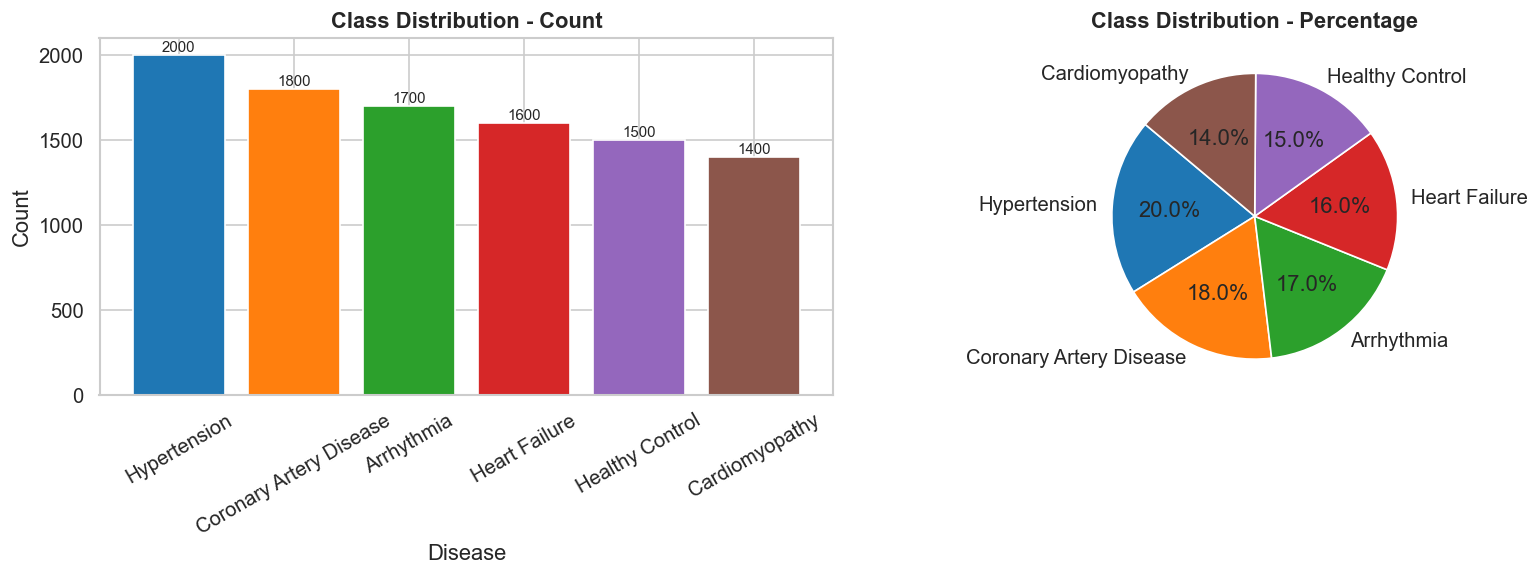

In [67]:
counts = df["disease"].value_counts()
colors = sns.color_palette("tab10", len(counts))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(counts.index, counts.values, color=colors, edgecolor="white")
ax1.set_xlabel("Disease")
ax1.set_ylabel("Count")
ax1.set_title("Class Distribution - Count", fontweight="bold")
ax1.tick_params(axis="x", rotation=30)
for i, v in enumerate(counts.values):
    ax1.text(i, v + 20, str(v), ha="center", fontsize=9)

ax2.pie(counts.values, labels=counts.index, autopct="%1.1f%%",
        colors=colors, startangle=140, wedgeprops={"edgecolor": "white"})
ax2.set_title("Class Distribution - Percentage", fontweight="bold")

plt.tight_layout()
plt.savefig("figures/disease_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


### 3.3 Correlation heatmap

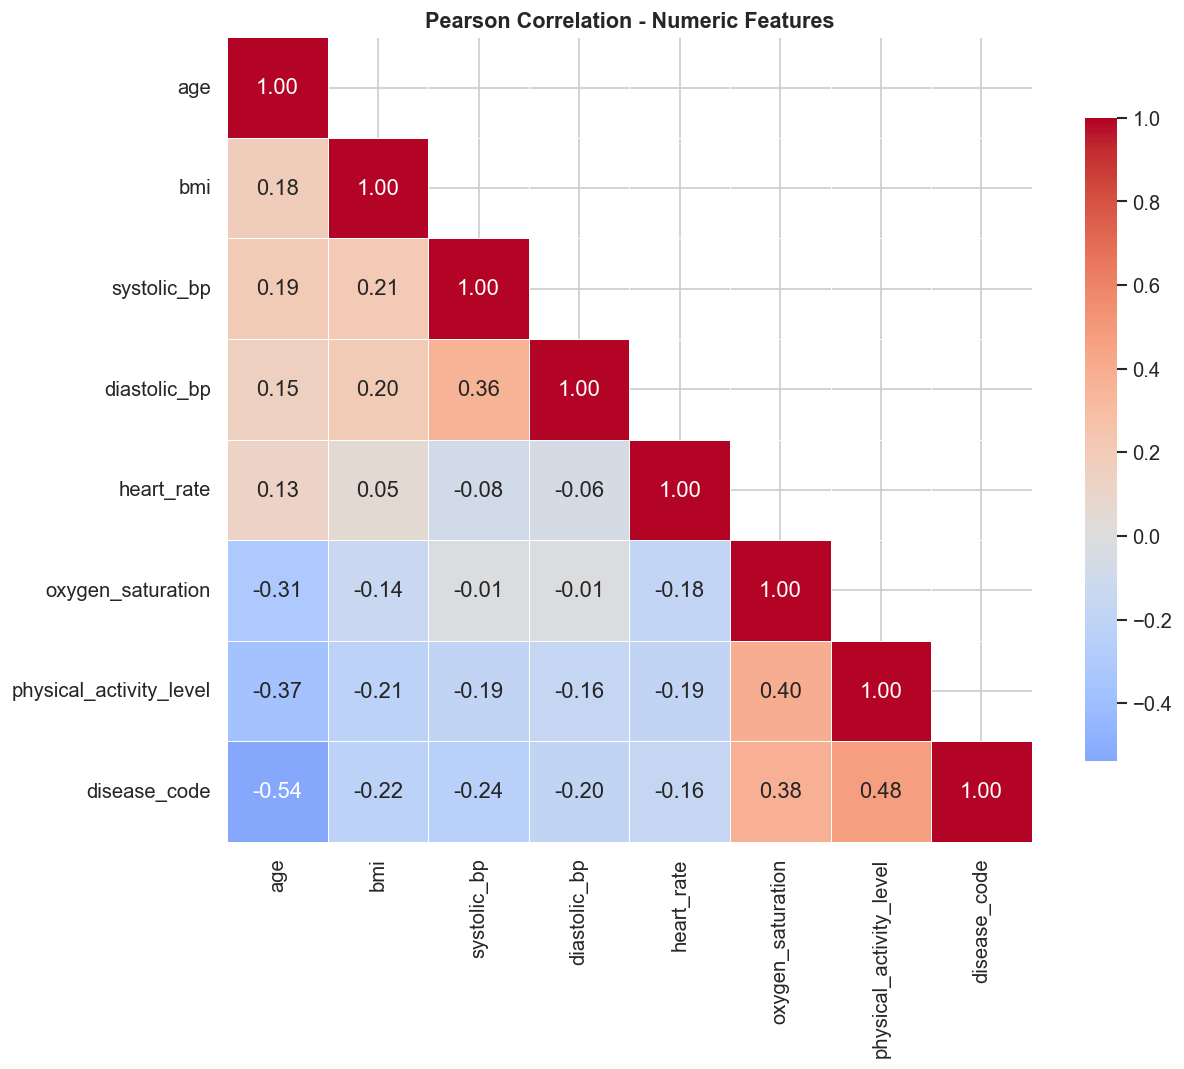

In [68]:
# Only numeric columns plus the encoded label are included here
corr = df[NUMERIC_COLS + ["disease_code"]].dropna().corr()

# Mask the upper triangle to avoid redundant information
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Pearson Correlation - Numeric Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


### 3.4 Histograms - continuous features by disease class

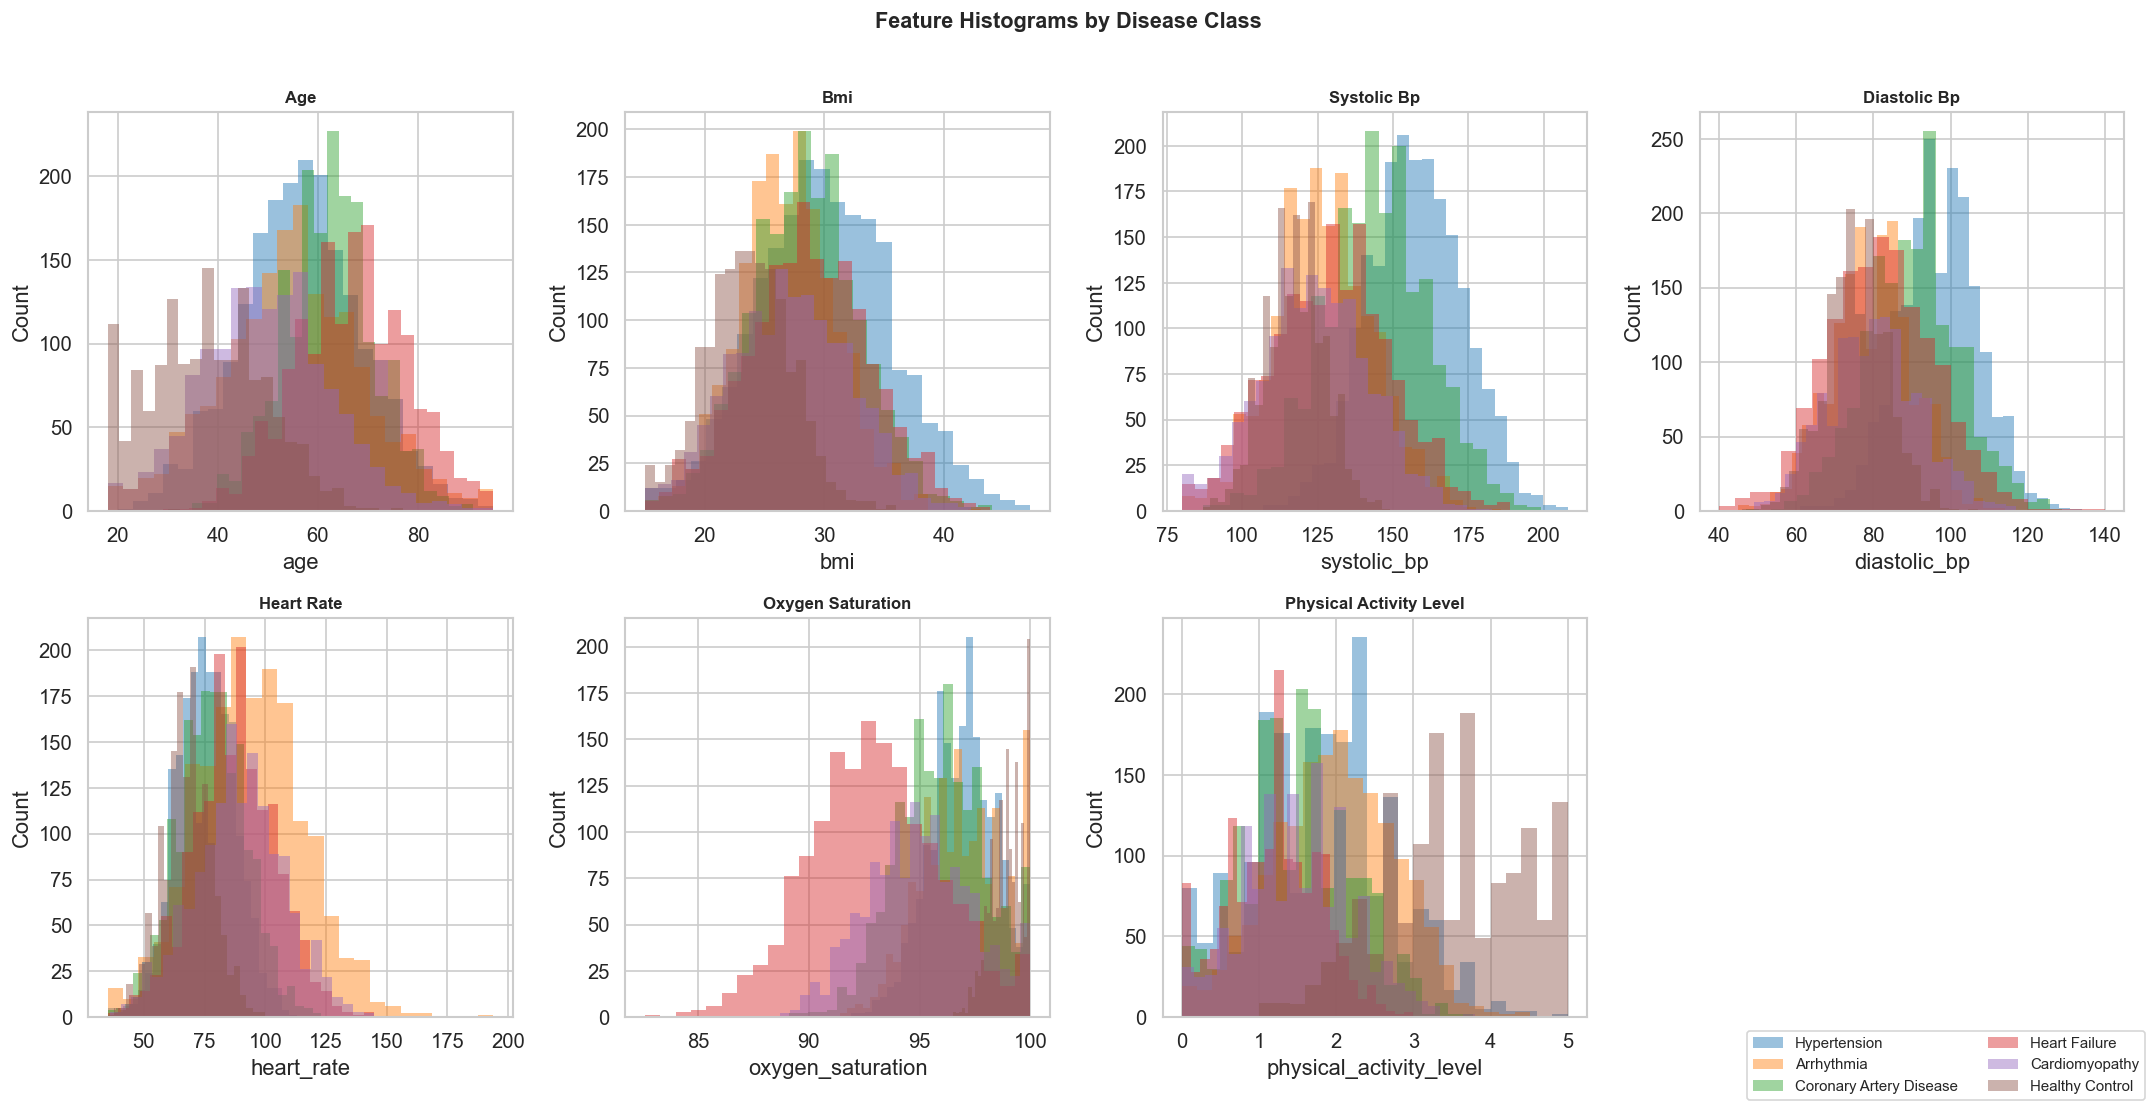

In [69]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_COLS):
    ax = axes[i]
    for j, disease in enumerate(df["disease"].unique()):
        subset = df[df["disease"] == disease][col].dropna()
        ax.hist(subset, bins=25, alpha=0.45,
                label=disease, color=PALETTE[j % len(PALETTE)], edgecolor="none")
    ax.set_title(col.replace("_", " ").title(), fontsize=10, fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

axes[-1].axis("off")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower right", fontsize=9, ncol=2)
fig.suptitle("Feature Histograms by Disease Class", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("figures/histograms.png", dpi=150, bbox_inches="tight")
plt.show()


### 3.5 Box plots - spread and outliers

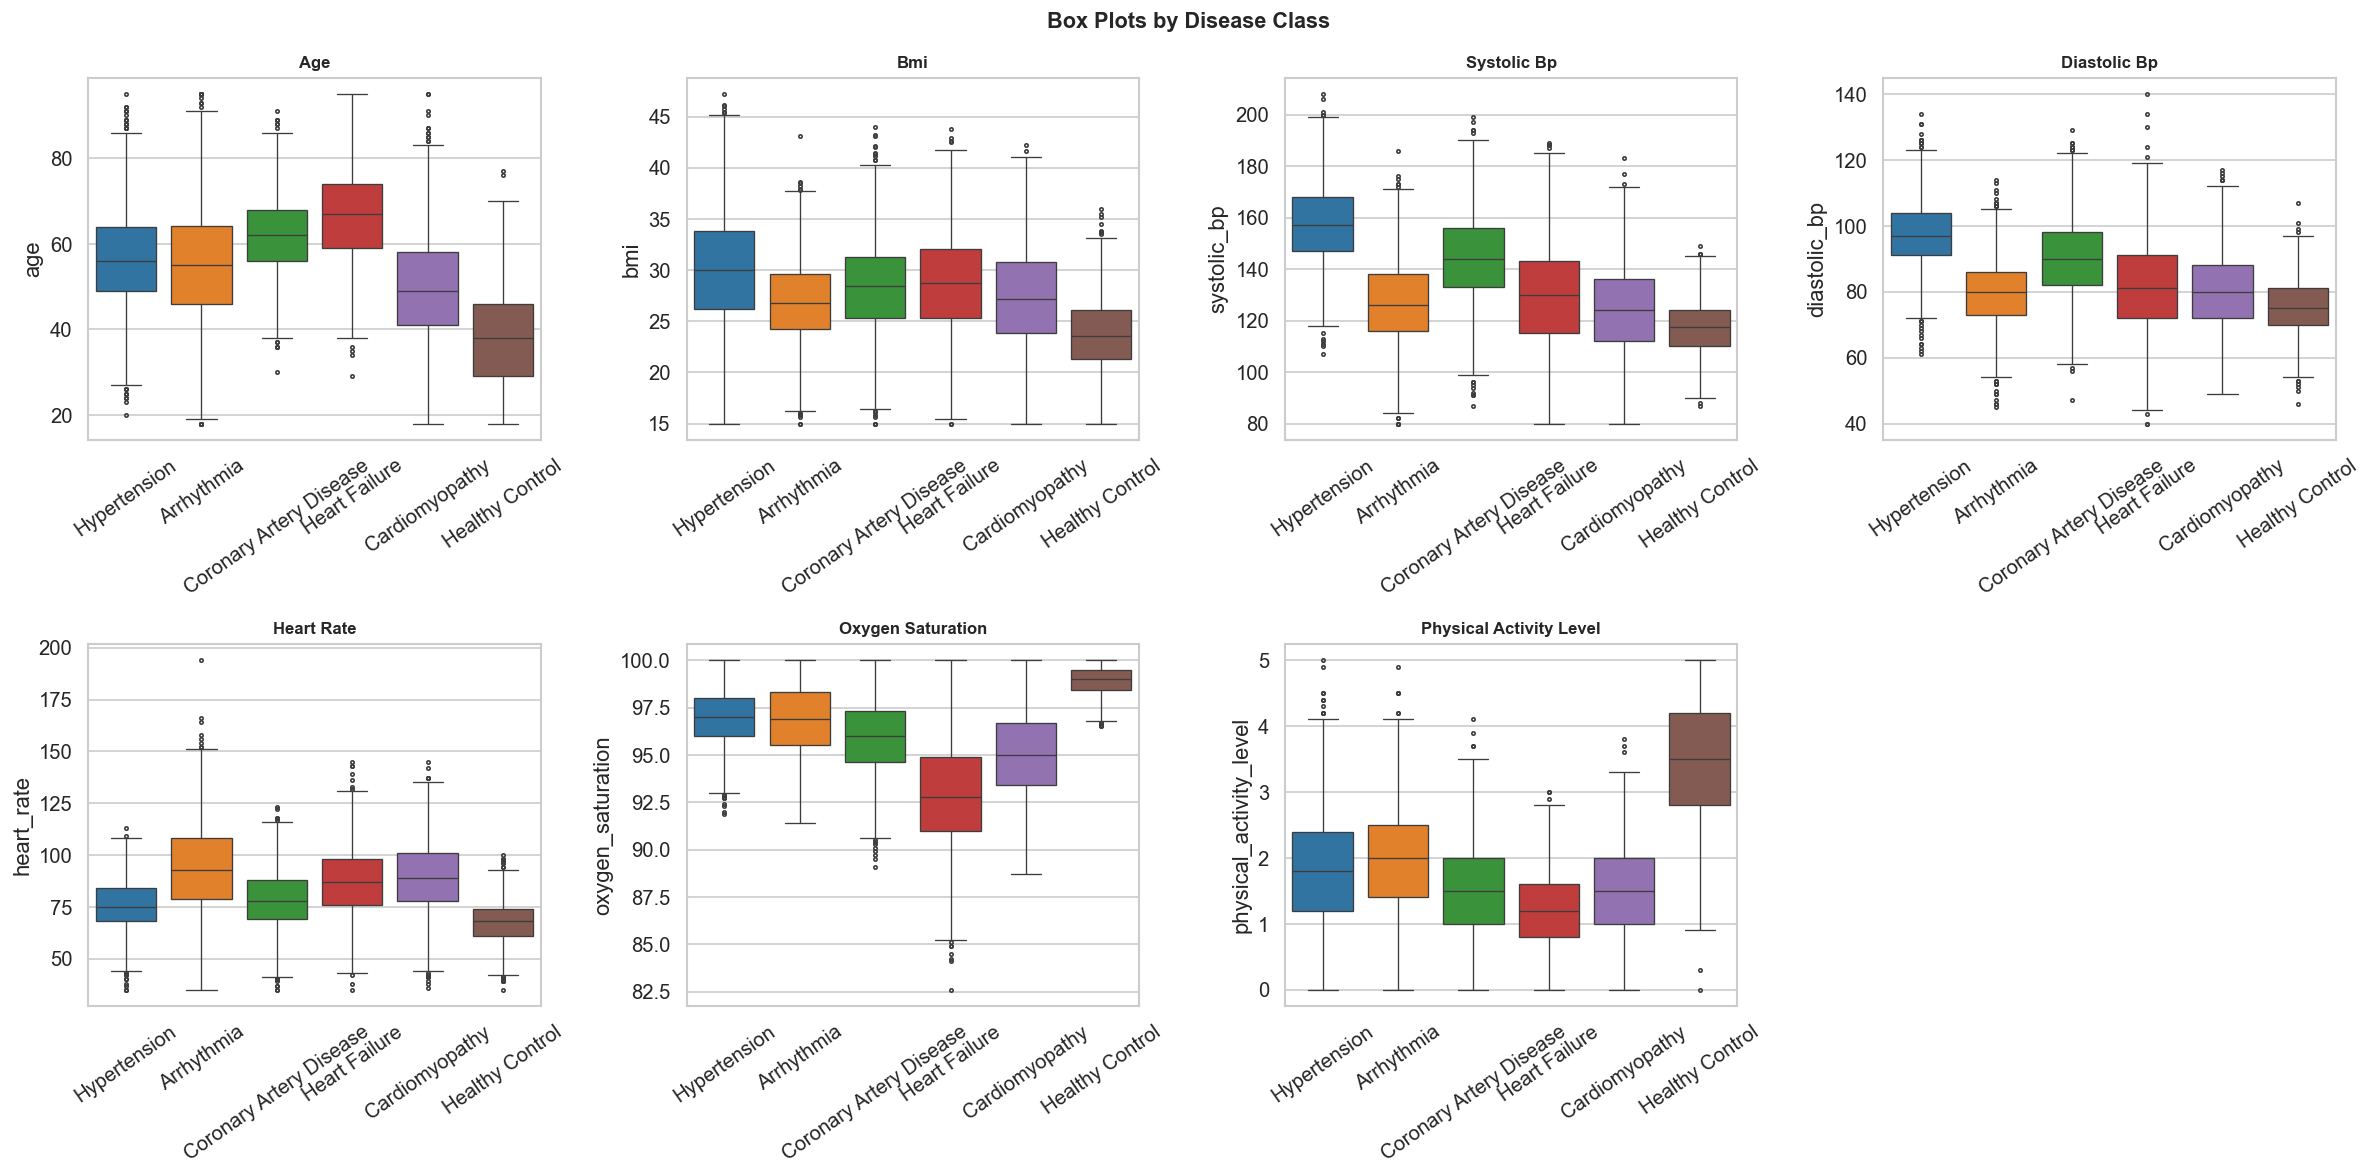

In [70]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_COLS):
    sns.boxplot(data=df, x="disease", y=col, ax=axes[i],
                palette="tab10", fliersize=2, linewidth=0.8)
    axes[i].set_title(col.replace("_", " ").title(), fontsize=10, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=35)

axes[-1].axis("off")
fig.suptitle("Box Plots by Disease Class", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/boxplots.png", dpi=150, bbox_inches="tight")
plt.show()


### 3.6 Pairplot

A random subsample is used here to keep rendering time manageable.
100 records per class gives a reasonable picture of inter-feature relationships.

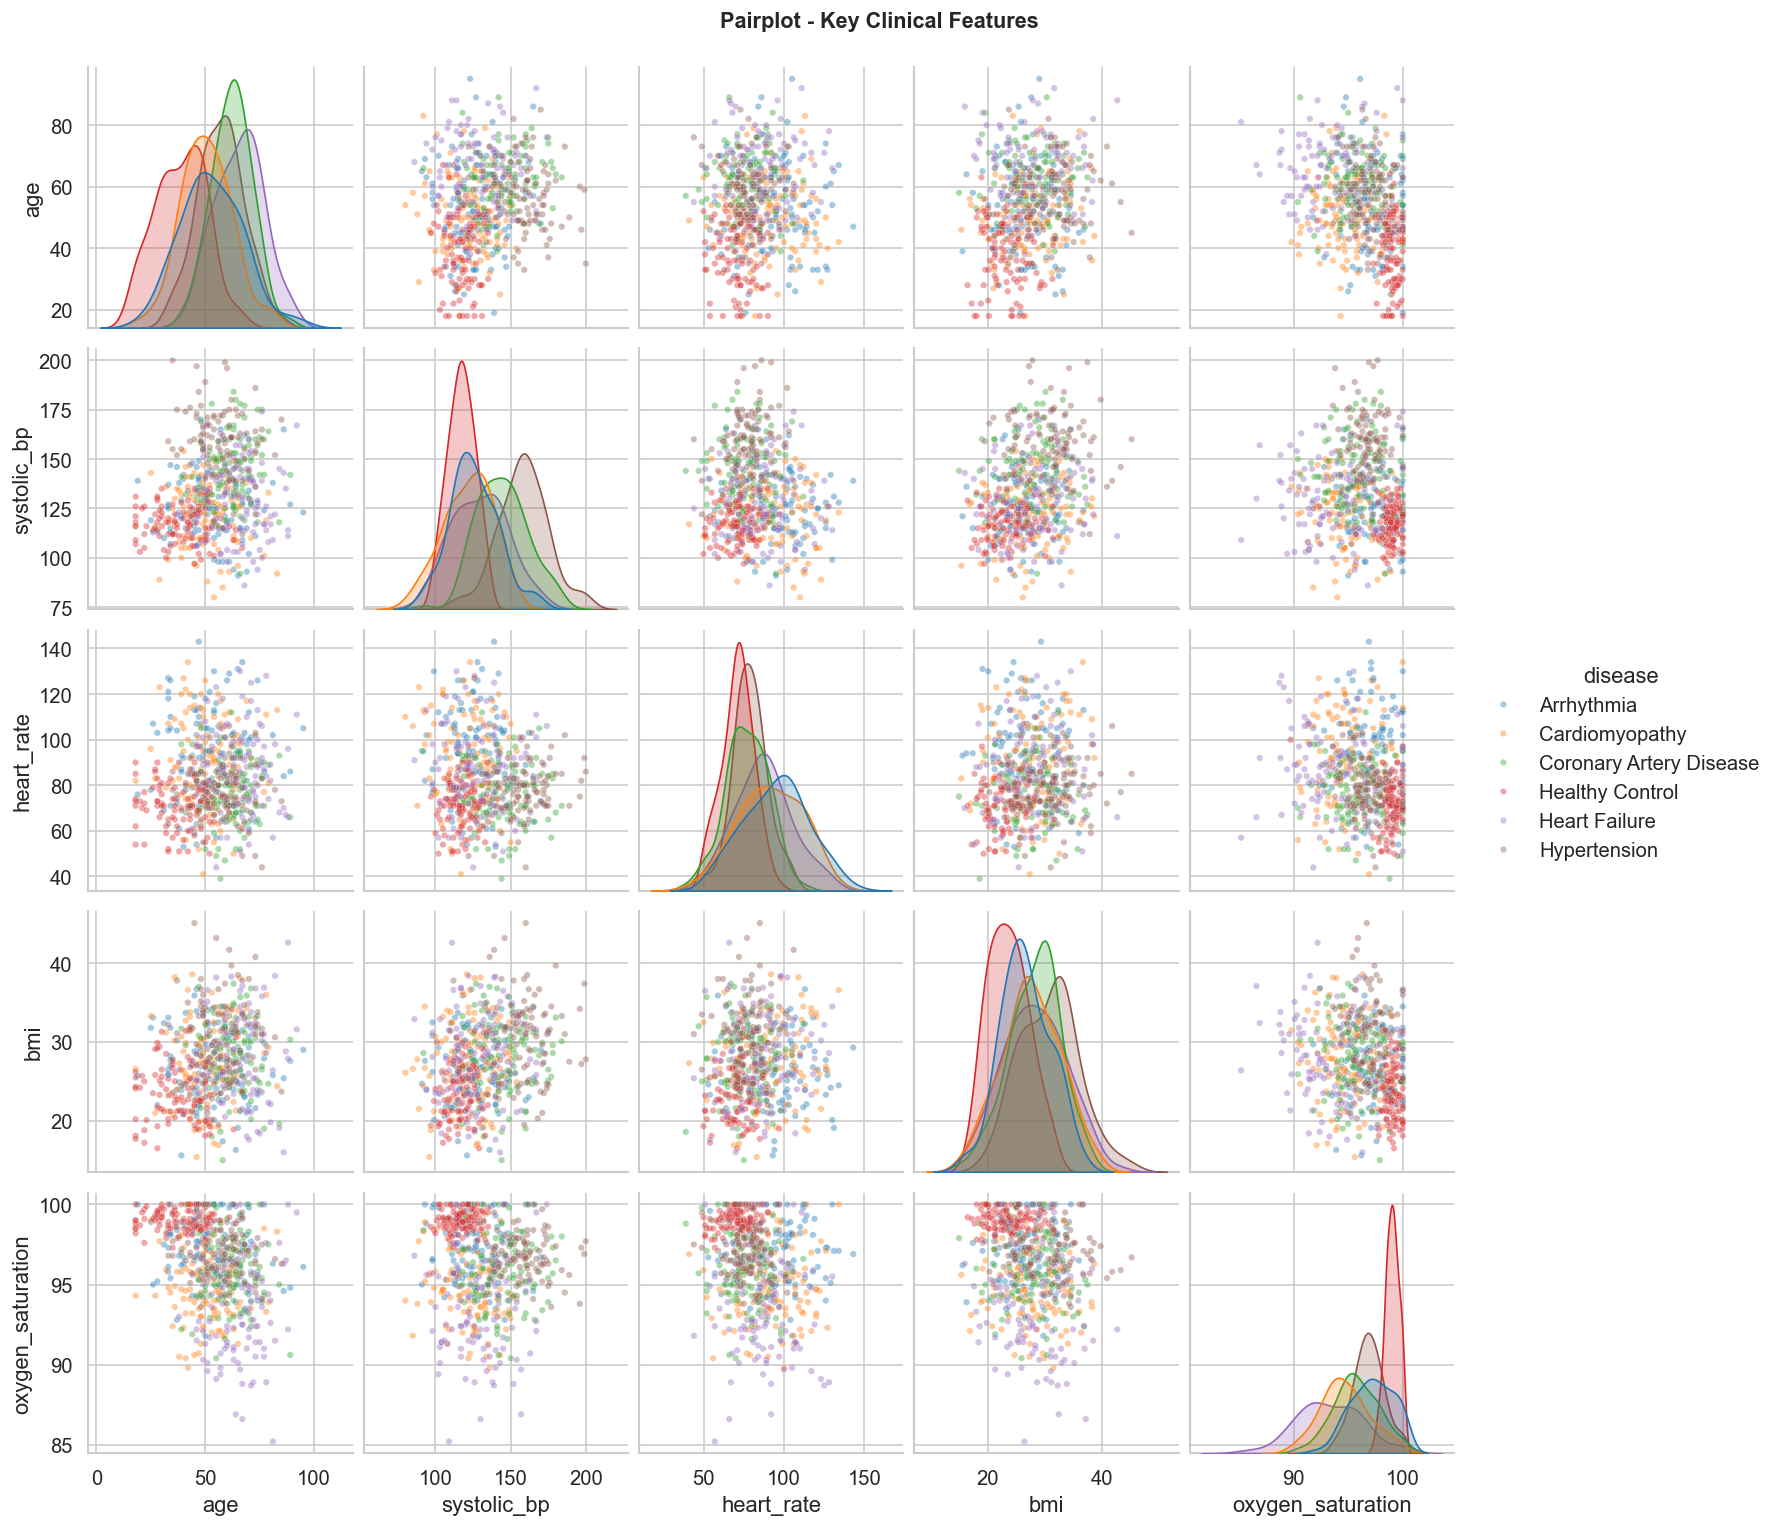

In [71]:
sub_cols = ["age", "systolic_bp", "heart_rate", "bmi", "oxygen_saturation", "disease"]
sample = (
    df[sub_cols].dropna()
    .groupby("disease", group_keys=False)
    .apply(lambda x: x.sample(min(len(x), 100), random_state=SEED))
)

g = sns.pairplot(sample, hue="disease", diag_kind="kde",
                 plot_kws={"alpha": 0.4, "s": 15}, palette="tab10")
g.fig.suptitle("Pairplot - Key Clinical Features", y=1.02, fontsize=13, fontweight="bold")
plt.savefig("figures/pairplot.png", dpi=120, bbox_inches="tight")
plt.show()


### 3.7 Symptom prevalence by disease class

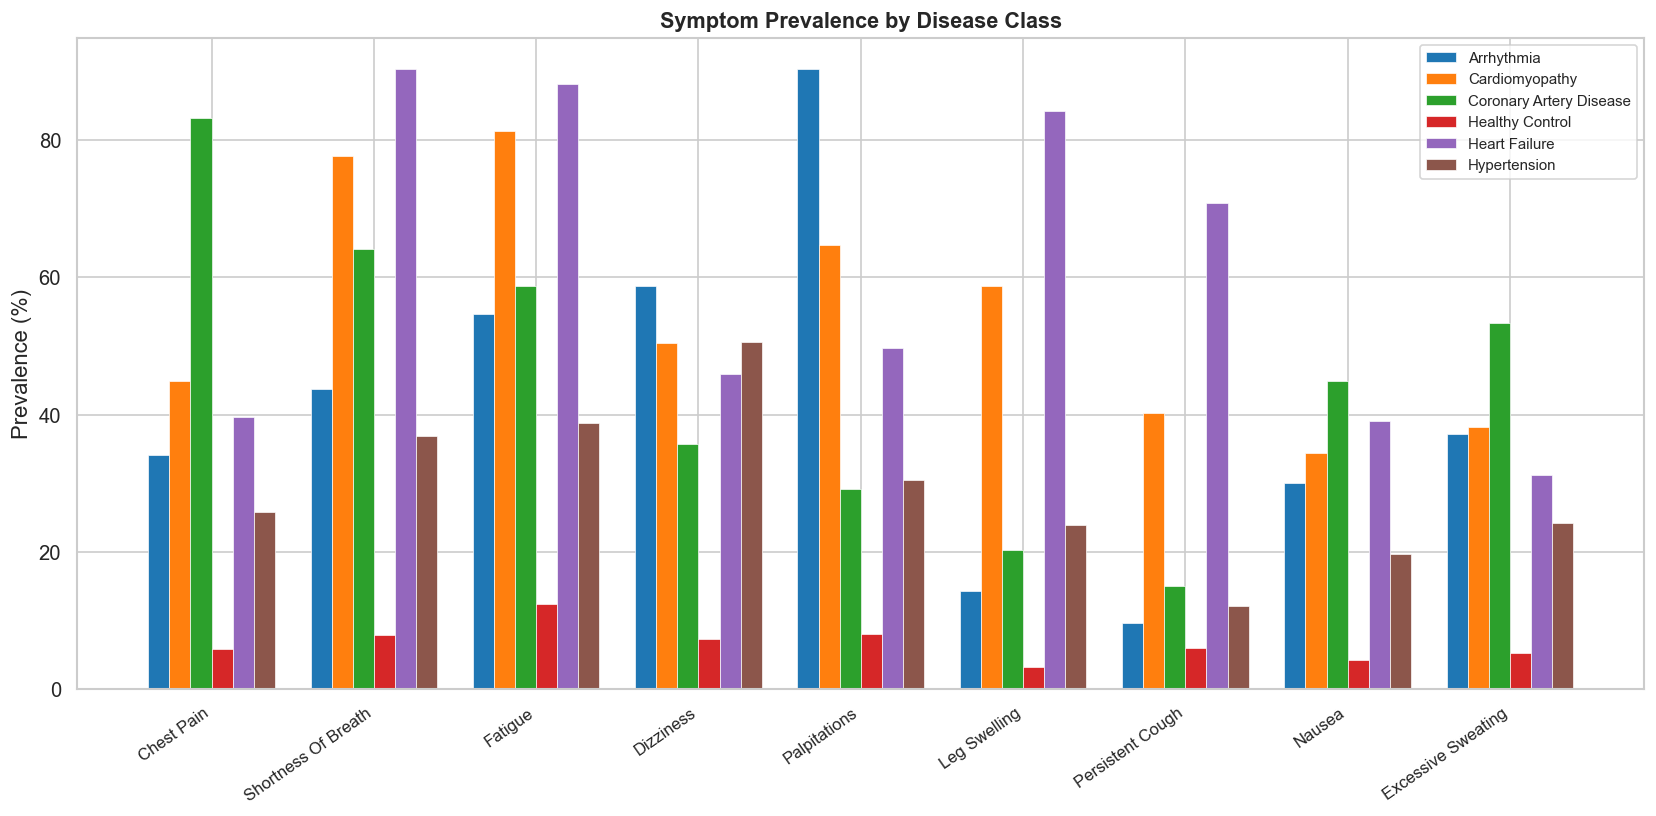

In [72]:
freq = df.groupby("disease")[SYMPTOM_COLS].mean().mul(100).round(1)
x = np.arange(len(SYMPTOM_COLS))
w = 0.13

fig, ax = plt.subplots(figsize=(14, 7))
for i, (disease, row) in enumerate(freq.iterrows()):
    ax.bar(x + i * w, row.values, width=w,
           label=disease, color=PALETTE[i], edgecolor="white", linewidth=0.4)

ax.set_xticks(x + w * (len(freq) - 1) / 2)
ax.set_xticklabels([c.replace("_", " ").title() for c in SYMPTOM_COLS],
                   rotation=35, ha="right", fontsize=10)
ax.set_ylabel("Prevalence (%)")
ax.set_title("Symptom Prevalence by Disease Class", fontsize=13, fontweight="bold")
ax.legend(fontsize=9, loc="upper right")
plt.tight_layout()
plt.savefig("figures/symptom_frequency.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Data Preprocessing

### 4.1 Imputation, outlier handling, scaling, and splitting

The preprocessing steps applied here:

- **Median imputation** for continuous features (robust to skew)
- **Mode imputation** for binary features
- **IQR-based capping** at 3x IQR to handle extreme values without discarding rows
- **StandardScaler** on numeric columns only (binary features are already 0/1)
- **Stratified 80/20 train-test split** to preserve class proportions

In [73]:
df_proc = df.copy()

# Impute missing values
num_imp = SimpleImputer(strategy="median")
df_proc[NUMERIC_COLS] = num_imp.fit_transform(df_proc[NUMERIC_COLS])

bin_imp = SimpleImputer(strategy="most_frequent")
df_proc[BINARY_COLS]  = bin_imp.fit_transform(df_proc[BINARY_COLS])

print(f"Missing values remaining: {df_proc.isnull().sum().sum()}")

# Cap outliers using IQR Winsorisation (factor = 3)
for col in NUMERIC_COLS:
    q1, q3 = df_proc[col].quantile(0.25), df_proc[col].quantile(0.75)
    iqr    = q3 - q1
    lo, hi = q1 - 3 * iqr, q3 + 3 * iqr
    n_out  = ((df_proc[col] < lo) | (df_proc[col] > hi)).sum()
    df_proc[col] = df_proc[col].clip(lo, hi)
    if n_out:
        print(f"  Capped {n_out} outliers in '{col}'")

# Encode the target label
le = LabelEncoder()
y  = le.fit_transform(df_proc["disease"])

# Save the encoder and class mapping for use in the Streamlit app
class_map = {int(le.transform([c])[0]): c for c in le.classes_}
joblib.dump(le, "models/label_encoder.pkl")
with open("models/class_map.json", "w") as fh:
    json.dump(class_map, fh, indent=2)

# Build feature matrix
X = df_proc[FEATURE_COLS].copy()
X[BINARY_COLS] = X[BINARY_COLS].astype(int)

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

# Scale numeric features - fit on train, apply to both
scaler = StandardScaler()
X_train_s = X_train.copy()
X_test_s  = X_test.copy()
X_train_s[NUMERIC_COLS] = scaler.fit_transform(X_train[NUMERIC_COLS])
X_test_s[NUMERIC_COLS]  = scaler.transform(X_test[NUMERIC_COLS])
joblib.dump(scaler, "models/scaler.pkl")

# Cross-validation object for training
SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print(f"Train size: {X_train_s.shape[0]}  |  Test size: {X_test_s.shape[0]}")
print(f"Classes: {list(le.classes_)}")
print("Preprocessing done. Scaler and encoder saved.")


Missing values remaining: 0
  Capped 2 outliers in 'heart_rate'
  Capped 1 outliers in 'oxygen_saturation'
Train size: 8000  |  Test size: 2000
Classes: ['Arrhythmia', 'Cardiomyopathy', 'Coronary Artery Disease', 'Healthy Control', 'Heart Failure', 'Hypertension']
Preprocessing done. Scaler and encoder saved.


### 4.2 Verify class balance in train and test splits

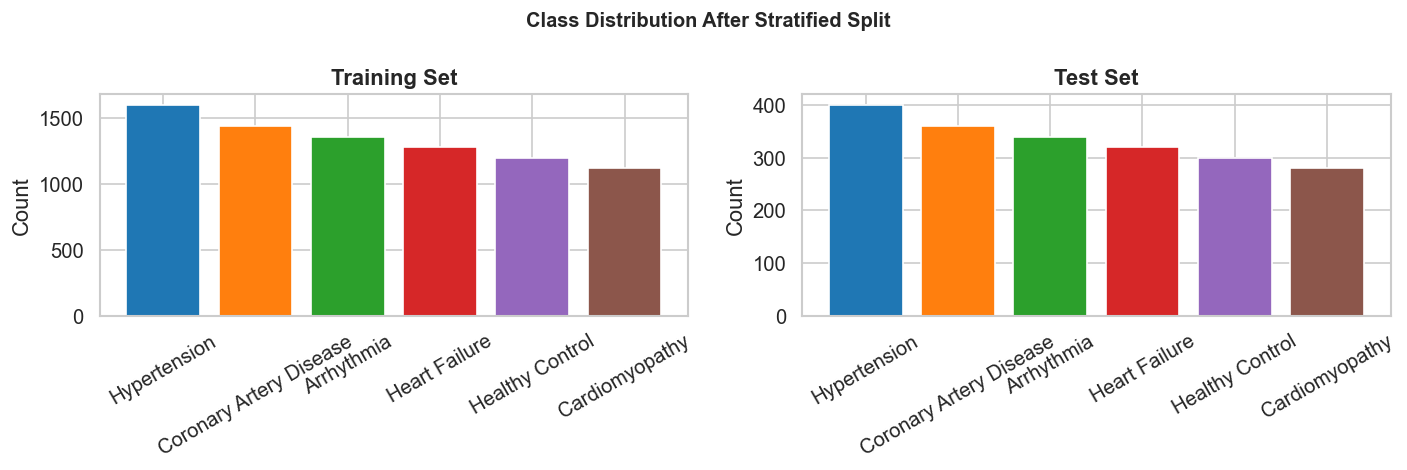

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_split, title in zip(axes, [y_train, y_test], ["Training Set", "Test Set"]):
    counts = pd.Series(y_split).map(class_map).value_counts()
    ax.bar(counts.index, counts.values, color=PALETTE[:len(counts)], edgecolor="white")
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("Class Distribution After Stratified Split", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


## 5. Model Training

### 5.1 Model configurations

Eight classifiers are trained and compared. XGBoost and LightGBM are used if installed;
otherwise the notebook falls back to GradientBoostingClassifier and ExtraTreesClassifier
respectively - both are solid alternatives.

Hyperparameter grids are intentionally kept focused rather than exhaustive.
The goal is a fair comparison, not an exhaustive search that takes hours.

In [75]:
MODEL_CONFIGS = {
    "Logistic Regression": {
        "model":  LogisticRegression(max_iter=1000, random_state=SEED),
        "params": {
            "C":      [0.1, 1, 10],
            "solver": ["lbfgs", "saga"],
        },
    },
    "Decision Tree": {
        "model":  DecisionTreeClassifier(random_state=SEED),
        "params": {
            "max_depth":         [5, 10, None],
            "min_samples_split": [2, 10],
            "criterion":         ["gini", "entropy"],
        },
    },
    "Random Forest": {
        "model":  RandomForestClassifier(random_state=SEED, n_jobs=-1),
        "params": {
            "n_estimators":      [100, 200],
            "max_depth":         [10, None],
            "min_samples_split": [2, 5],
        },
    },
    "XGBoost": {
        "model": (
            XGBClassifier(eval_metric="mlogloss", use_label_encoder=False,
                          random_state=SEED, n_jobs=-1)
            if HAS_XGB else
            GradientBoostingClassifier(random_state=SEED)
        ),
        "params": {
            "n_estimators":  [100, 200],
            "max_depth":     [4, 6],
            "learning_rate": [0.1, 0.2],
        },
    },
    "LightGBM": {
        "model": (
            LGBMClassifier(random_state=SEED, n_jobs=-1, verbose=-1)
            if HAS_LGBM else
            ExtraTreesClassifier(random_state=SEED, n_jobs=-1)
        ),
        "params": (
            {"n_estimators": [100, 200], "max_depth": [5, 10], "learning_rate": [0.05, 0.1]}
            if HAS_LGBM else
            {"n_estimators": [100, 200], "max_depth": [10, None]}
        ),
    },
    "SVM": {
        "model":  SVC(probability=True, random_state=SEED),
        "params": {
            "C":      [1, 10],
            "kernel": ["rbf", "linear"],
        },
    },
    "KNN": {
        "model":  KNeighborsClassifier(n_jobs=-1),
        "params": {
            "n_neighbors": [5, 11],
            "weights":     ["uniform", "distance"],
        },
    },
    "Naive Bayes": {
        "model":  GaussianNB(),
        "params": {
            "var_smoothing": [1e-9, 1e-7],
        },
    },
}

print(f"Models to train: {list(MODEL_CONFIGS.keys())}")


Models to train: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost', 'LightGBM', 'SVM', 'KNN', 'Naive Bayes']


### 5.2 Train all models

GridSearchCV with 5-fold stratified cross-validation is used to tune each model.
The best estimator from each search is saved to disk.

SVM is the slowest here - on 8,000 training records it can take 15-20 minutes on its own.
If you're short on time, consider reducing the SVM param grid or skipping it temporarily.

In [76]:
trained_models   = {}
training_results = {}

for name, cfg in MODEL_CONFIGS.items():
    print(f"Training: {name}")
    t0 = time.time()

    gs = GridSearchCV(
        estimator=cfg["model"],
        param_grid=cfg["params"],
        cv=SKF,
        scoring="f1_macro",
        n_jobs=-1,
        refit=True,
        verbose=0,
    )
    gs.fit(X_train_s, y_train)

    # Report cross-validation accuracy on the refit best estimator
    cv_scores = cross_val_score(
        gs.best_estimator_, X_train_s, y_train,
        cv=SKF, scoring="accuracy", n_jobs=-1
    )
    elapsed = round(time.time() - t0, 1)

    print(f"  Best params : {gs.best_params_}")
    print(f"  CV accuracy : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}  ({elapsed}s)")

    safe_name = name.lower().replace(" ", "_")
    joblib.dump(gs.best_estimator_, f"models/{safe_name}.pkl")

    trained_models[name]   = gs.best_estimator_
    training_results[name] = {
        "best_params":      str(gs.best_params_),
        "cv_accuracy_mean": round(cv_scores.mean(), 4),
        "cv_accuracy_std":  round(cv_scores.std(),  4),
        "train_time_s":     elapsed,
    }

# Pick the best model overall by cross-validation accuracy
best_name  = max(training_results, key=lambda k: training_results[k]["cv_accuracy_mean"])
best_model = trained_models[best_name]
joblib.dump(best_model, "models/best_model.pkl")
with open("models/best_model_name.json", "w") as fh:
    json.dump({"name": best_name,
               "cv_accuracy": training_results[best_name]["cv_accuracy_mean"]}, fh, indent=2)

training_df = pd.DataFrame(training_results).T
training_df.to_csv("results/training_summary.csv")

print(f"\nBest model: {best_name}  (CV accuracy = {training_results[best_name]['cv_accuracy_mean']:.4f})")
print("All models saved to models/")
display(training_df)


Training: Logistic Regression
  Best params : {'C': 10, 'solver': 'saga'}
  CV accuracy : 0.8005 +/- 0.0141  (4.0s)
Training: Decision Tree
  Best params : {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 2}
  CV accuracy : 0.6847 +/- 0.0123  (0.4s)
Training: Random Forest
  Best params : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
  CV accuracy : 0.7913 +/- 0.0104  (5.4s)
Training: XGBoost
  Best params : {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100}
  CV accuracy : 0.7951 +/- 0.0141  (71.6s)
Training: LightGBM
  Best params : {'max_depth': None, 'n_estimators': 200}
  CV accuracy : 0.7650 +/- 0.0089  (2.6s)
Training: SVM
  Best params : {'C': 1, 'kernel': 'rbf'}
  CV accuracy : 0.8091 +/- 0.0104  (15.4s)
Training: KNN
  Best params : {'n_neighbors': 11, 'weights': 'distance'}
  CV accuracy : 0.7714 +/- 0.0091  (0.4s)
Training: Naive Bayes
  Best params : {'var_smoothing': 1e-09}
  CV accuracy : 0.7983 +/- 0.0116  (0.1s)

Best model: SVM  

,best_params,cv_accuracy_mean,cv_accuracy_std,train_time_s
Logistic Regression,"{'C': 10, 'solver': 'saga'}",0.8005,0.0141,4.0
Decision Tree,"{'criterion': 'gini', 'max_depth': 10, 'min_sa...",0.6848,0.0123,0.4
Random Forest,"{'max_depth': None, 'min_samples_split': 2, 'n...",0.7912,0.0104,5.4
XGBoost,"{'learning_rate': 0.1, 'max_depth': 4, 'n_esti...",0.7951,0.0141,71.6
LightGBM,"{'max_depth': None, 'n_estimators': 200}",0.765,0.0089,2.6
SVM,"{'C': 1, 'kernel': 'rbf'}",0.8091,0.0104,15.4
KNN,"{'n_neighbors': 11, 'weights': 'distance'}",0.7714,0.0091,0.4
Naive Bayes,{'var_smoothing': 1e-09},0.7982,0.0116,0.1


## 6. Model Evaluation

### 6.1 Test-set metrics for all models

In [77]:
def compute_metrics(model, X, y):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)
    y_bin  = label_binarize(y, classes=list(range(len(le.classes_))))
    return {
        "accuracy":  round(accuracy_score(y, y_pred),                                    4),
        "precision": round(precision_score(y, y_pred, average="macro", zero_division=0), 4),
        "recall":    round(recall_score(y, y_pred,    average="macro", zero_division=0), 4),
        "f1_macro":  round(f1_score(y, y_pred,        average="macro", zero_division=0), 4),
        "roc_auc":   round(roc_auc_score(y_bin, y_prob, average="macro", multi_class="ovr"), 4),
    }, y_pred, y_prob


all_metrics = {}
all_preds   = {}
all_probs   = {}

for name, model in trained_models.items():
    m, y_pred, y_prob = compute_metrics(model, X_test_s, y_test)
    all_metrics[name] = m
    all_preds[name]   = y_pred
    all_probs[name]   = y_prob

comparison_df = pd.DataFrame(all_metrics).T
comparison_df.index.name = "Model"
comparison_df.to_csv("results/model_comparison.csv")
comparison_df.to_csv("results/final_metrics.csv")

display(comparison_df.sort_values("f1_macro", ascending=False)
        .style.highlight_max(color="lightgreen", axis=0))


,accuracy,precision,recall,f1_macro,roc_auc
Model,,,,,
SVM,0.827500,0.826600,0.824700,0.825300,0.969200
Logistic Regression,0.819500,0.817800,0.816200,0.816500,0.968900
XGBoost,0.806000,0.806700,0.804200,0.805300,0.965800
Random Forest,0.808500,0.807400,0.804600,0.805000,0.964000
Naive Bayes,0.808000,0.806000,0.804200,0.804900,0.969700
LightGBM,0.774500,0.773000,0.770800,0.770400,0.955700
KNN,0.771000,0.766900,0.764200,0.761400,0.949300
Decision Tree,0.704000,0.707700,0.702900,0.704400,0.888100


### 6.2 Model comparison chart

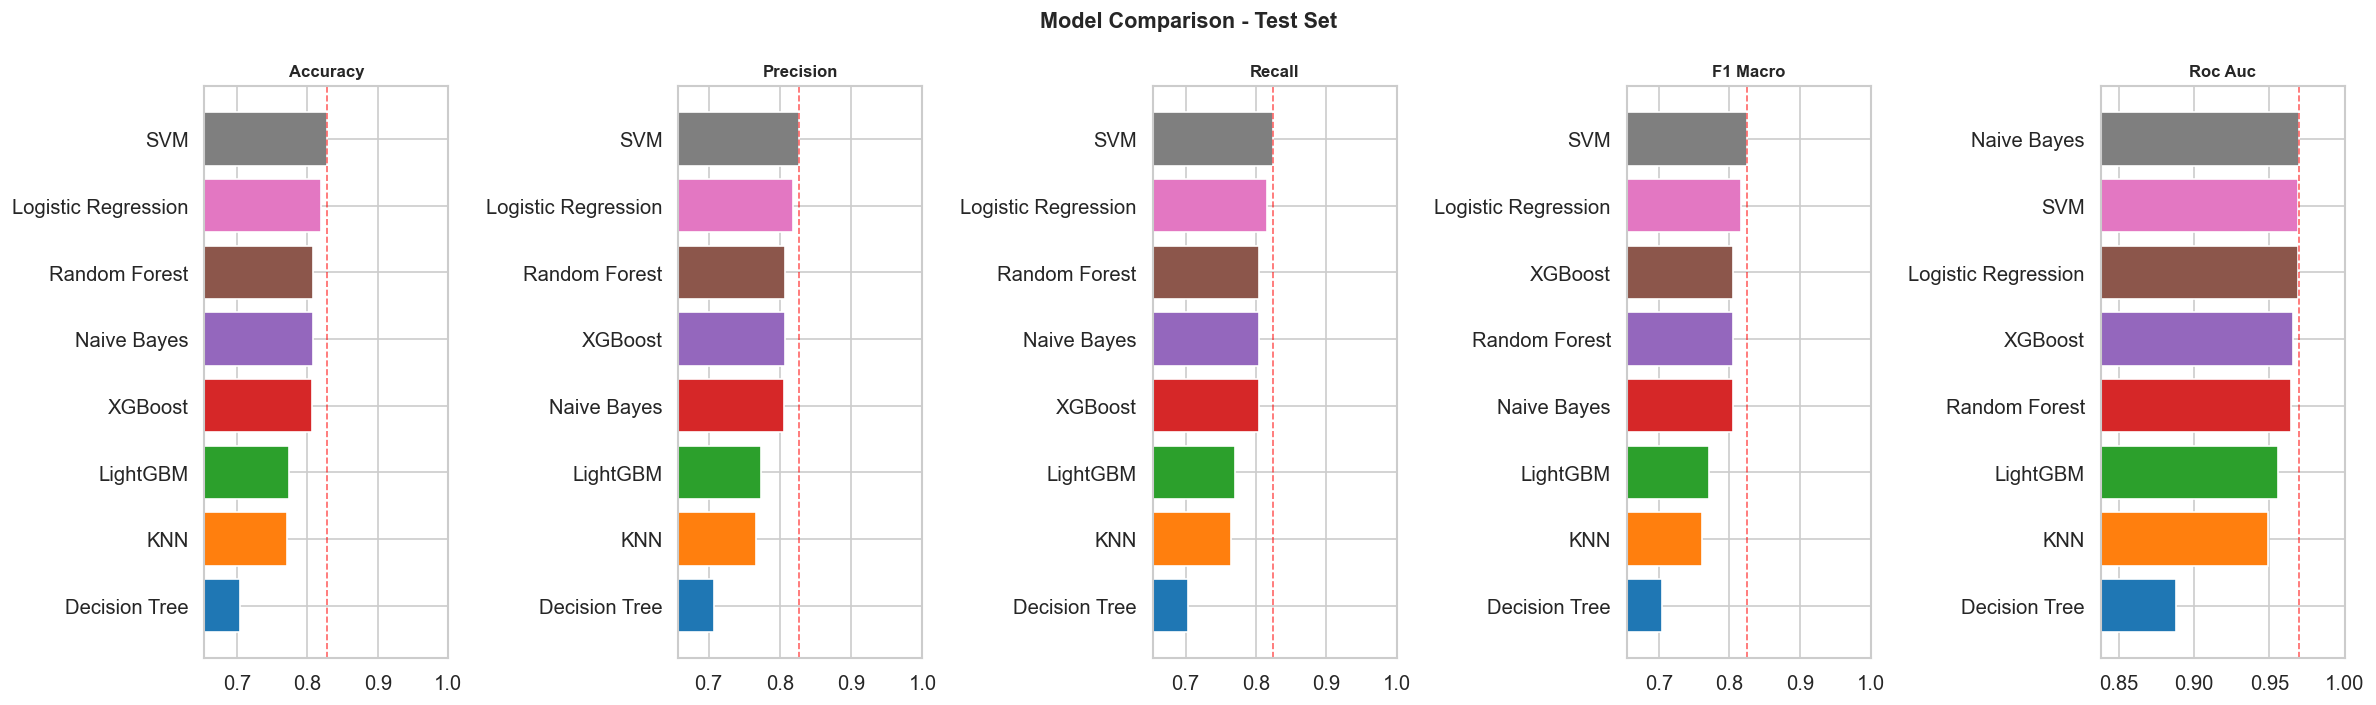

In [78]:
metrics_list = ["accuracy", "precision", "recall", "f1_macro", "roc_auc"]
fig, axes = plt.subplots(1, 5, figsize=(20, 6))

for ax, metric in zip(axes, metrics_list):
    vals   = comparison_df[metric].sort_values(ascending=True)
    colors = [PALETTE[i % len(PALETTE)] for i in range(len(vals))]
    ax.barh(vals.index, vals.values, color=colors)
    ax.set_xlim(max(0, vals.min() - 0.05), 1.0)
    ax.set_title(metric.replace("_", " ").title(), fontweight="bold", fontsize=10)
    ax.axvline(vals.max(), color="red", linestyle="--", lw=1, alpha=0.6)

fig.suptitle("Model Comparison - Test Set", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


### 6.3 Confusion matrices

All eight models are shown side by side. Values are expressed as a percentage of
each true class (row-normalised) so that class imbalance does not distort the picture.

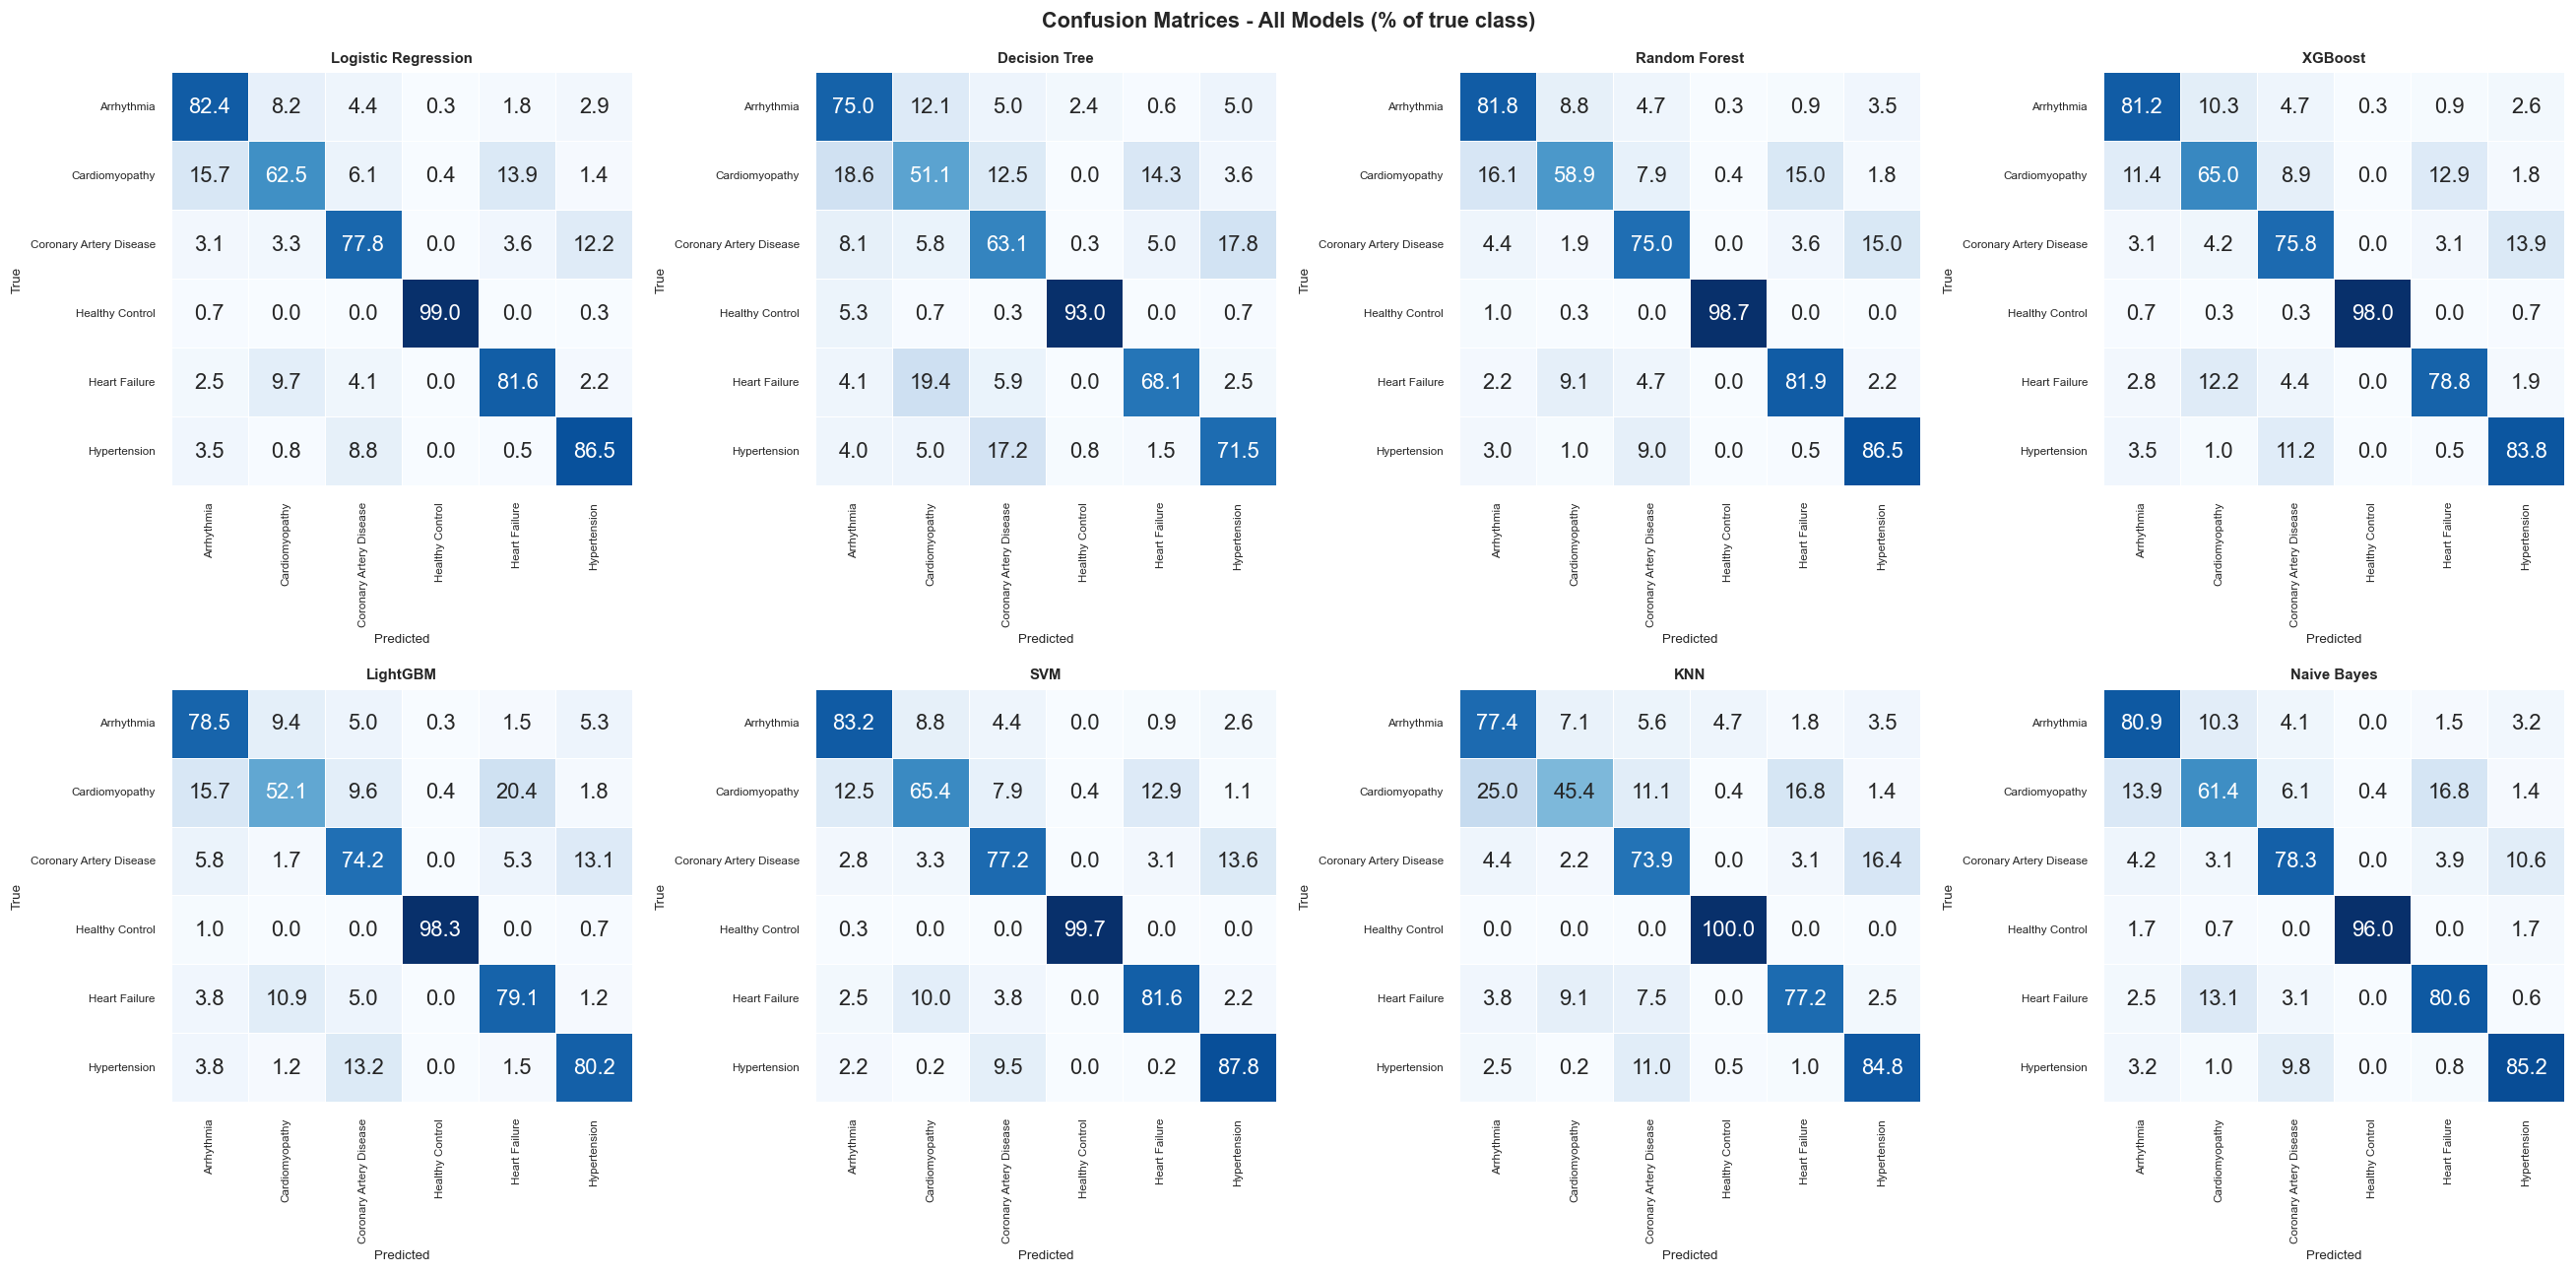

In [79]:
fig, axes = plt.subplots(2, 4, figsize=(22, 11))
axes = axes.flatten()

for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred = all_preds[name]
    cm  = confusion_matrix(y_test, y_pred)
    pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(pct, annot=True, fmt=".1f", cmap="Blues",
                xticklabels=le.classes_, yticklabels=le.classes_,
                ax=ax, linewidths=0.4, cbar=False)
    ax.set_title(name, fontweight="bold", fontsize=9)
    ax.set_xlabel("Predicted", fontsize=8)
    ax.set_ylabel("True", fontsize=8)
    ax.tick_params(labelsize=7)

for i in range(len(trained_models), len(axes)):
    axes[i].axis("off")

fig.suptitle("Confusion Matrices - All Models (% of true class)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/confusion_matrices_all.png", dpi=150, bbox_inches="tight")
plt.show()


### 6.4 ROC curves - best model

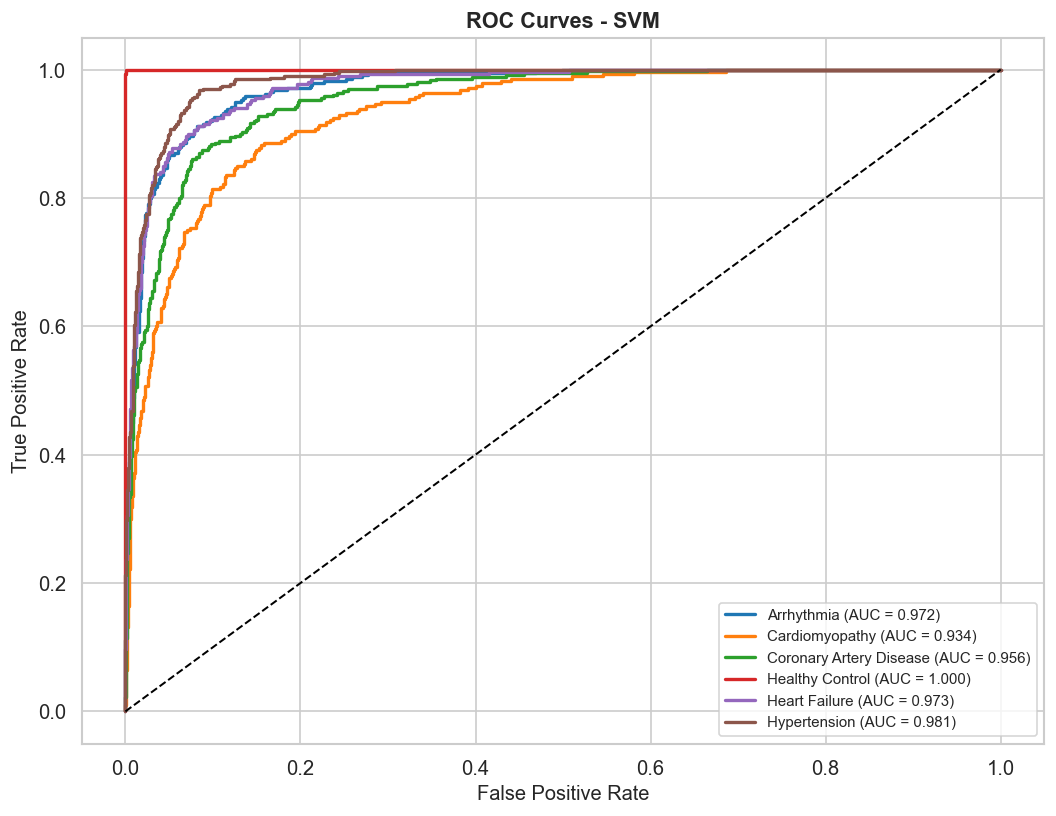

In [80]:
y_prob_best = all_probs[best_name]
y_bin       = label_binarize(y_test, classes=list(range(len(le.classes_))))

fig, ax = plt.subplots(figsize=(9, 7))

for i, (cname, col) in enumerate(zip(le.classes_, cycle(PALETTE))):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob_best[:, i])
    roc_val     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=col, lw=2, label=f"{cname} (AUC = {roc_val:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1.2)
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title(f"ROC Curves - {best_name}", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig("figures/roc_best_model.png", dpi=150, bbox_inches="tight")
plt.show()


### 6.5 Precision-Recall curves - best model

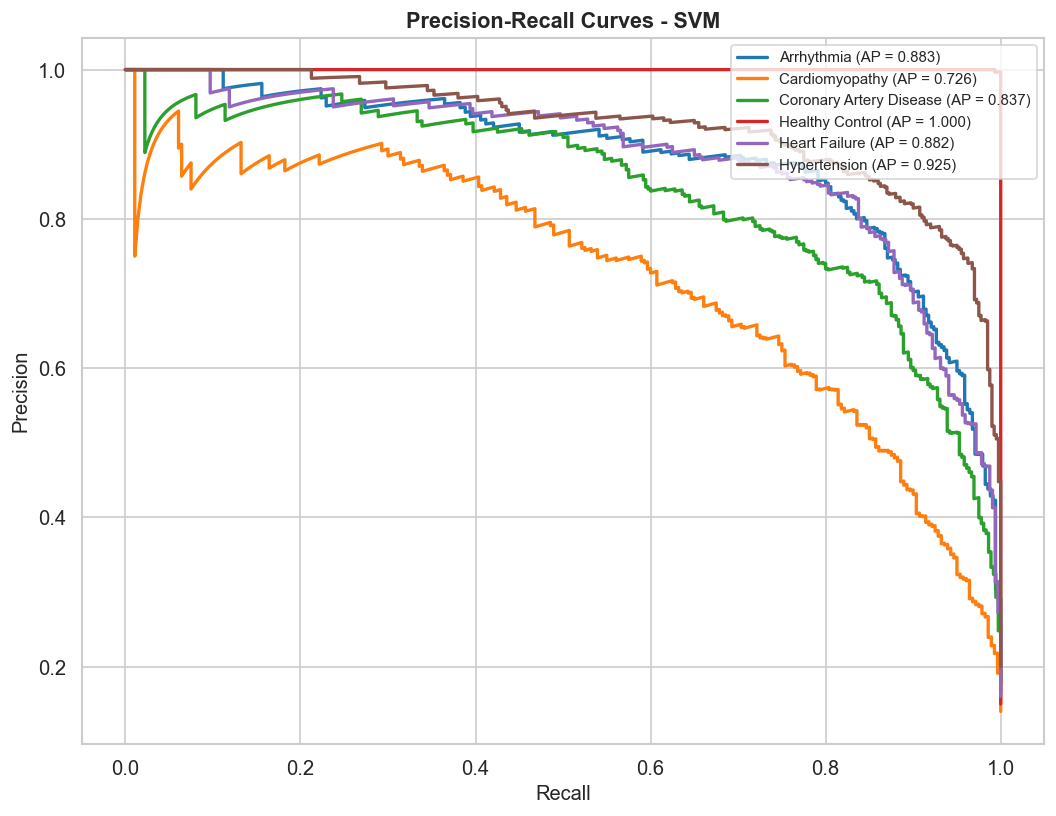

In [81]:
fig, ax = plt.subplots(figsize=(9, 7))

for i, (cname, col) in enumerate(zip(le.classes_, cycle(PALETTE))):
    prec, rec, _ = precision_recall_curve(y_bin[:, i], y_prob_best[:, i])
    ap = average_precision_score(y_bin[:, i], y_prob_best[:, i])
    ax.plot(rec, prec, color=col, lw=2, label=f"{cname} (AP = {ap:.3f})")

ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title(f"Precision-Recall Curves - {best_name}", fontsize=13, fontweight="bold")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig("figures/pr_best_model.png", dpi=150, bbox_inches="tight")
plt.show()


### 6.6 Per-class classification report - best model

In [82]:
report = classification_report(
    y_test, all_preds[best_name],
    target_names=le.classes_,
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report).T.round(4)
report_df.to_csv("results/classification_report_best_model.csv")
display(report_df)


,precision,recall,f1-score,support
Arrhythmia,0.8179,0.8324,0.8251,340.0000
Cardiomyopathy,0.7093,0.6536,0.6803,280.0000
Coronary Artery Disease,0.7616,0.7722,0.7669,360.0000
Healthy Control,0.9967,0.9967,0.9967,300.0000
Heart Failure,0.8365,0.8156,0.8259,320.0000
Hypertension,0.8377,0.8775,0.8571,400.0000
accuracy,0.8275,0.8275,0.8275,0.8275
macro avg,0.8266,0.8247,0.8253,2000.0000
weighted avg,0.8263,0.8275,0.8266,2000.0000


## 7. Feature Importance Analysis

### 7.1 Extract importances

Tree-based models (Random Forest, XGBoost, LightGBM, Decision Tree) expose
`feature_importances_` directly. For the remaining models (Logistic Regression,
SVM, KNN, Naive Bayes), permutation importance is used instead - it measures
how much the model's accuracy drops when each feature's values are randomly shuffled.

In [83]:
TREE_BASED = {"Random Forest", "XGBoost", "LightGBM", "Decision Tree"}

all_imp = {}

for name, model in trained_models.items():
    if name in TREE_BASED:
        imp = pd.Series(model.feature_importances_, index=FEATURE_COLS, name=name)
    else:
        result = permutation_importance(
            model, X_test_s, y_test,
            n_repeats=10, random_state=SEED, n_jobs=-1
        )
        imp = pd.Series(result.importances_mean, index=FEATURE_COLS, name=name)
    all_imp[name] = imp
    print(f"  {name}: done")

importance_df = pd.DataFrame(all_imp)
importance_df.index.name = "feature"
importance_df.to_csv("results/feature_importance.csv")
print("\nSaved: results/feature_importance.csv")
display(importance_df.round(4))


  Logistic Regression: done
  Decision Tree: done
  Random Forest: done
  XGBoost: done
  LightGBM: done
  SVM: done
  KNN: done
  Naive Bayes: done

Saved: results/feature_importance.csv


,Logistic Regression,Decision Tree,Random Forest,XGBoost,LightGBM,SVM,KNN,Naive Bayes
feature,,,,,,,,
age,0.0778,0.0915,0.0956,0.0913,0.0777,0.0895,0.0596,0.0714
bmi,0.0105,0.0210,0.0589,0.0218,0.0524,0.0151,0.0071,0.0070
systolic_bp,0.0951,0.1585,0.1221,0.1540,0.0983,0.1044,0.0774,0.0835
diastolic_bp,0.0506,0.0760,0.0923,0.0703,0.0774,0.0619,0.0481,0.0458
heart_rate,0.0269,0.0474,0.0767,0.0483,0.0601,0.0436,0.0290,0.0369
oxygen_saturation,0.0754,0.1485,0.1272,0.1657,0.0844,0.0996,0.0726,0.0900
physical_activity_level,0.0387,0.1461,0.0986,0.1327,0.0804,0.0513,0.0305,0.0366
gender,0.0031,0.0032,0.0109,0.0012,0.0226,0.0040,-0.0067,0.0023
chest_pain,0.0570,0.0723,0.0451,0.0687,0.0541,0.0531,0.0428,0.0594


### 7.2 Top 15 features - best model

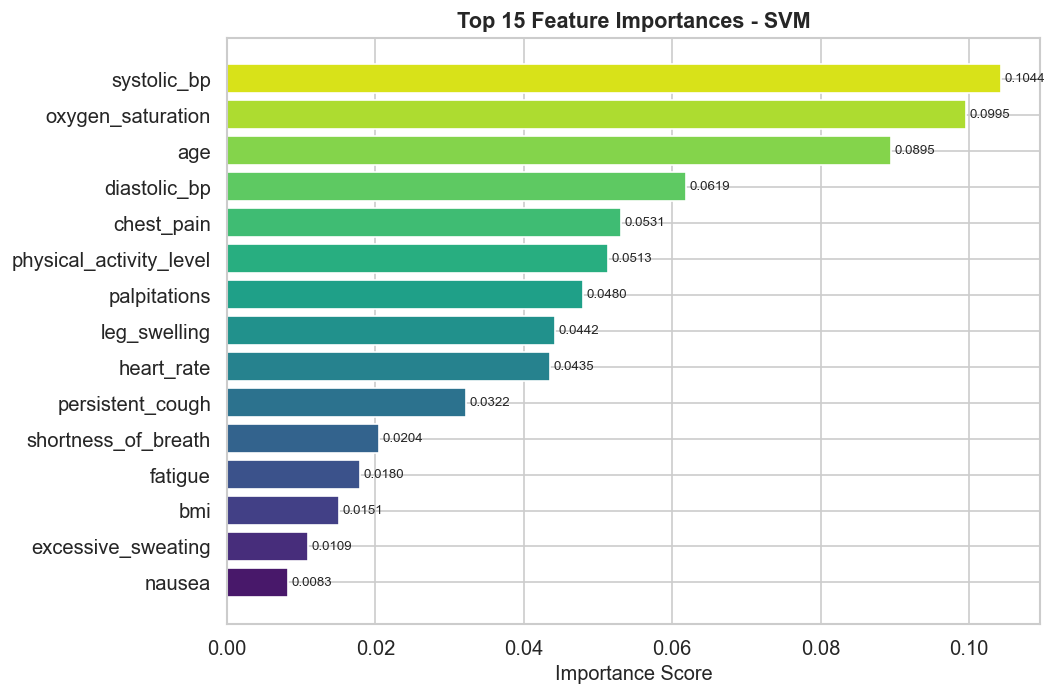

In [84]:
top15 = importance_df[best_name].nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top15.index, top15.values,
               color=sns.color_palette("viridis", len(top15)))
ax.set_xlabel("Importance Score", fontsize=12)
ax.set_title(f"Top 15 Feature Importances - {best_name}", fontsize=13, fontweight="bold")

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.0005, bar.get_y() + bar.get_height() / 2,
            f"{w:.4f}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("figures/feature_importance_best.png", dpi=150, bbox_inches="tight")
plt.show()


### 7.3 Importance heatmap across all models

Each column is normalised 0-1 so models with different importance scales can be
compared on the same axis. Features that rank consistently high across multiple
models are likely the most reliable predictors.

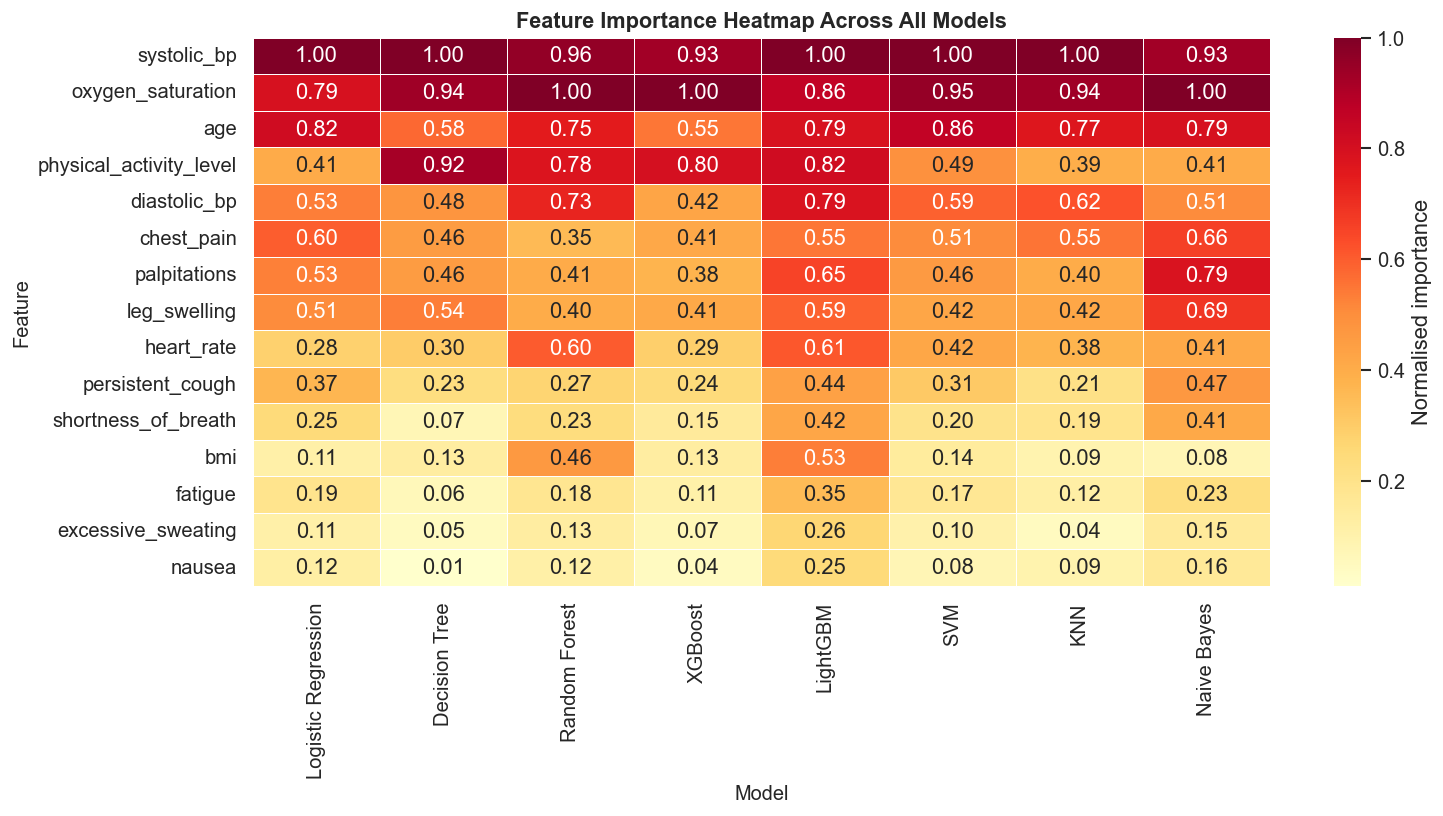

In [85]:
norm = importance_df.div(importance_df.max(axis=0))
top15_feats = norm.mean(axis=1).nlargest(15).index

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(norm.loc[top15_feats], annot=True, fmt=".2f", cmap="YlOrRd",
            linewidths=0.4, ax=ax, cbar_kws={"label": "Normalised importance"})
ax.set_title("Feature Importance Heatmap Across All Models", fontsize=13, fontweight="bold")
ax.set_xlabel("Model", fontsize=12)
ax.set_ylabel("Feature", fontsize=12)
plt.tight_layout()
plt.savefig("figures/feature_importance_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Results Export and LaTeX Assets

### 8.1 Check all output files

In [86]:
print("CSV results:")
for f in sorted(Path("results").glob("*.csv")):
    print(f"  {f.name}  ({f.stat().st_size:,} bytes)")

print()
print("Figures:")
for f in sorted(Path("figures").glob("*.png")):
    print(f"  {f.name}")


CSV results:
  classification_report_best_model.csv  (416 bytes)
  feature_importance.csv  (3,599 bytes)
  final_metrics.csv  (415 bytes)
  model_comparison.csv  (415 bytes)
  summary_statistics.csv  (484 bytes)
  training_summary.csv  (663 bytes)

Figures:
  boxplots.png
  confusion_matrices_all.png
  correlation_heatmap.png
  disease_distribution.png
  feature_importance_best.png
  feature_importance_heatmap.png
  histograms.png
  model_comparison.png
  pairplot.png
  pr_best_model.png
  roc_best_model.png
  symptom_frequency.png


### 8.2 LaTeX table - model comparison

The function below converts a DataFrame to a properly formatted LaTeX table
using booktabs-style rules.

In [87]:
def df_to_latex(df, caption, label, float_fmt="{:.4f}"):
    cols    = df.columns.tolist()
    col_fmt = "l" + "r" * len(cols)
    lines   = [
        r"\begin{table}[htbp]",
        r"  \centering",
        rf"  \caption{{{caption}}}",
        rf"  \label{{tab:{label}}}",
        rf"  \begin{{tabular}}{{{col_fmt}}}",
        r"    \toprule",
        "    " + (df.index.name or "Model") + " & " + " & ".join(str(c) for c in cols) + r" \\",
        r"    \midrule",
    ]
    for idx, row in df.iterrows():
        vals = []
        for v in row:
            try:    vals.append(float_fmt.format(float(v)))
            except: vals.append(str(v))
        lines.append(f"    {idx} & " + " & ".join(vals) + r" \\")
    lines += [r"    \bottomrule", r"  \end{tabular}", r"\end{table}"]
    return "\n".join(lines)


comp_latex = df_to_latex(
    comparison_df.sort_values("f1_macro", ascending=False),
    caption="Test-set performance metrics for all trained classifiers.",
    label="model_comparison",
)
Path("results/table_model_comparison.tex").write_text(comp_latex)
print("Saved: results/table_model_comparison.tex")
print()
print(comp_latex[:600])


Saved: results/table_model_comparison.tex

\begin{table}[htbp]
  \centering
  \caption{Test-set performance metrics for all trained classifiers.}
  \label{tab:model_comparison}
  \begin{tabular}{lrrrrr}
    \toprule
    Model & accuracy & precision & recall & f1_macro & roc_auc \\
    \midrule
    SVM & 0.8275 & 0.8266 & 0.8247 & 0.8253 & 0.9692 \\
    Logistic Regression & 0.8195 & 0.8178 & 0.8162 & 0.8165 & 0.9689 \\
    XGBoost & 0.8060 & 0.8067 & 0.8042 & 0.8053 & 0.9658 \\
    Random Forest & 0.8085 & 0.8074 & 0.8046 & 0.8050 & 0.9640 \\
    Naive Bayes & 0.8080 & 0.8060 & 0.8042 & 0.8049 & 0.9697 \\
    LightGBM & 0.7745 & 0.7730


###  Feature Importance

In [88]:
fi_latex = df_to_latex(
    importance_df.round(4),
    caption="Feature importance scores across all trained models.",
    label="feature_importance",
)
Path("results/table_feature_importance.tex").write_text(fi_latex)
print("Saved: results/table_feature_importance.tex")


Saved: results/table_feature_importance.tex


### 8.4 Figure blocks

Each figure used in the dissertation is listed below with a caption and label.

In [89]:
def fig_latex(filename, caption, label, width=r"0.85\\textwidth"):
    return textwrap.dedent(rf"""
        \\begin{{figure}}[htbp]
          \\centering
          \\includegraphics[width={width}]{{figures/{filename}}}
          \\caption{{{caption}}}
          \\label{{fig:{label}}}
        \\end{{figure}}
    """).strip()


figure_defs = [
    ("disease_distribution.png",       "Class distribution of the synthetic cardiovascular dataset.", "disease_dist"),
    ("correlation_heatmap.png",         "Pearson correlation matrix for all continuous features.", "corr_heatmap"),
    ("histograms.png",                  "Histograms of continuous features stratified by disease class.", "histograms"),
    ("boxplots.png",                    "Box plots of vital signs and demographic features by disease.", "boxplots"),
    ("symptom_frequency.png",           "Symptom prevalence rates across all disease classes.", "symptom_freq"),
    ("model_comparison.png",            "Comparison of all classifiers across five evaluation metrics.", "model_compare"),
    ("confusion_matrices_all.png",      "Row-normalised confusion matrices for all trained models.", "cm_all"),
    ("roc_best_model.png",              f"ROC curves for {best_name} (best performing model).", "roc_best"),
    ("pr_best_model.png",               f"Precision-Recall curves for {best_name}.", "pr_best"),
    ("feature_importance_best.png",     f"Top 15 feature importances for {best_name}.", "fi_best"),
    ("feature_importance_heatmap.png",  "Normalised feature importance heatmap across all models.", "fi_heatmap"),
]

blocks = [fig_latex(fn, cap, lbl) for fn, cap, lbl in figure_defs]
Path("results/figures_dissertation.tex").write_text("\n\n".join(blocks))
print(f"Saved: results/figures_dissertation.tex  ({len(figure_defs)} figure blocks)")


Saved: results/figures_dissertation.tex  (11 figure blocks)


### 8.5 Summary

In [90]:
print("=" * 58)
print("  Cardiovascular Disease Detection - Run Complete")
print("=" * 58)
print(f"  Dataset        {len(df):,} records, {len(FEATURE_COLS)} features, {len(CLASS_NAMES)} classes")
print(f"  Models trained {len(trained_models)}")
print(f"  Best model     {best_name}")
bm = all_metrics[best_name]
print(f"  Accuracy       {bm['accuracy']:.4f}")
print(f"  F1 (macro)     {bm['f1_macro']:.4f}")
print(f"  ROC-AUC        {bm['roc_auc']:.4f}")
print()
print("  Output files")
for f in sorted(Path("results").glob("*")):
    print(f"    results/{f.name}")
for f in sorted(Path("figures").glob("*.png")):
    print(f"    figures/{f.name}")
print("=" * 58)


  Cardiovascular Disease Detection - Run Complete
  Dataset        10,000 records, 20 features, 6 classes
  Models trained 8
  Best model     SVM
  Accuracy       0.8275
  F1 (macro)     0.8253
  ROC-AUC        0.9692

  Output files
    results/classification_report_best_model.csv
    results/feature_importance.csv
    results/figures_dissertation.tex
    results/final_metrics.csv
    results/model_comparison.csv
    results/summary_statistics.csv
    results/table_feature_importance.tex
    results/table_model_comparison.tex
    results/training_summary.csv
    figures/boxplots.png
    figures/confusion_matrices_all.png
    figures/correlation_heatmap.png
    figures/disease_distribution.png
    figures/feature_importance_best.png
    figures/feature_importance_heatmap.png
    figures/histograms.png
    figures/model_comparison.png
    figures/pairplot.png
    figures/pr_best_model.png
    figures/roc_best_model.png
    figures/symptom_frequency.png
